# Passos Mágicos — Análise Exploratória + Modelo Preditivo de Risco de Defasagem

**Datathon PosTech | Associação Passos Mágicos**

Este notebook responde às **10 perguntas** do desafio, construindo o entendimento **passo a
passo**: cada seção da Parte 1 carrega os dados um pouco mais, mostra uma tabela ou gráfico, e
conclui com a resposta à pergunta correspondente — antes de avançar para a próxima. A ideia é que
quem estiver lendo consiga acompanhar o raciocínio sem precisar já saber a resposta de antemão.

**Estrutura do notebook:**

- **Parte 0 — Preparação dos dados:** carga das 3 abas do `datathon.xlsx` (PEDE 2022/2023/2024),
  harmonização de nomes de coluna e correção de problemas de qualidade de dados.
- **Parte 1 — Análise exploratória, pergunta a pergunta:** respostas às Perguntas 1 a 8 (IAN,
  IDA, IEG, IAA, IPS, IPP, IPV e multidimensionalidade dos indicadores/INDE), cada uma com
  tabelas, gráficos e um parágrafo de conclusão.
- **Parte 2 — Pergunta 9 (modelo preditivo):** o modelo de Machine Learning que estima a
  probabilidade de um aluno entrar em risco de defasagem no ano seguinte — mantido tal como
  construído originalmente, com feature engineering → separação treino/teste → modelagem →
  avaliação → aplicação prática.
- **Complemento — mineração de texto (`Destaque IEG/IDA/IPV`):** técnicas de NLP
  (pré-processamento, bag-of-words, TF-IDF, clusterização e extração de regras) aplicadas aos
  campos de comentário padronizado da coorte 2022, para validar os achados das Perguntas 3, 7
  e 8 com um sinal qualitativo independente, e testar se agregam poder preditivo ao modelo da
  Pergunta 9.
- **Parte 3 — Pergunta 10 (efetividade do programa):** consolidação das evidências das partes
  anteriores para avaliar se o programa vem gerando impacto real ao longo dos ciclos.
- **Conclusão geral:** um resumo direto das 10 respostas.


In [1]:
import pandas as pd
import numpy as np
import re
import datetime
import warnings
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve, average_precision_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

CAMINHO_BASE = "datathon.xlsx"  # ajuste o caminho se necessário
CORES_ANO = {2022: "#c44e52", 2023: "#dd8452", 2024: "#4c72b0"}


## Parte 0 — Preparação dos dados

### 0.1 Carregamento e consolidação da base

O arquivo tem 3 abas (`PEDE2022`, `PEDE2023`, `PEDE2024`), uma por ano de pesquisa. Cada aba tem
**nomes de coluna diferentes** para os mesmos conceitos (ex.: `INDE 22` vs `INDE 2023` vs
`INDE 2024`; `Defas` vs `Defasagem`), então o primeiro passo é harmonizar tudo em um único
**painel (long format)**: uma linha por aluno × ano.


In [2]:
xls = pd.ExcelFile(CAMINHO_BASE)
d22 = pd.read_excel(xls, "PEDE2022")
d23 = pd.read_excel(xls, "PEDE2023")
d24 = pd.read_excel(xls, "PEDE2024")

for nome, d in [("PEDE2022", d22), ("PEDE2023", d23), ("PEDE2024", d24)]:
    print(f"{nome}: {d.shape[0]} alunos, {d.shape[1]} colunas")


PEDE2022: 860 alunos, 42 colunas
PEDE2023: 1014 alunos, 48 colunas
PEDE2024: 1156 alunos, 50 colunas


In [3]:
def harmonize(df, ano, inde_col, pedra_col, idade_col, nome_col, mat_col, por_col, ing_col,
              fase_ideal_col, defas_col):
    # Renomeia as colunas de uma aba anual para um esquema comum entre 2022/2023/2024.
    out = pd.DataFrame()
    out["RA"] = df["RA"].astype(str)
    out["Ano"] = ano
    out["Fase_raw"] = df["Fase"].astype(str)
    out["Nome"] = df[nome_col]
    out["Idade"] = df[idade_col]
    out["Genero"] = df["Gênero"]
    out["Ano_ingresso"] = df["Ano ingresso"]
    out["Instituicao"] = df["Instituição de ensino"]
    out["Pedra"] = df[pedra_col]
    out["INDE"] = df[inde_col]
    out["IAA"] = df["IAA"]
    out["IEG"] = df["IEG"]
    out["IPS"] = df["IPS"]
    out["IPP"] = df["IPP"] if "IPP" in df.columns else np.nan
    out["IDA"] = df["IDA"]
    out["Nota_Mat"] = df[mat_col]
    out["Nota_Por"] = df[por_col]
    out["IPV"] = df["IPV"]
    out["IAN"] = df["IAN"]
    out["Defasagem"] = df[defas_col]
    out["Atingiu_PV"] = df["Atingiu PV"] if "Atingiu PV" in df.columns else np.nan
    out["Destaque_IEG"] = df["Destaque IEG"] if "Destaque IEG" in df.columns else np.nan
    out["Destaque_IDA"] = df["Destaque IDA"] if "Destaque IDA" in df.columns else np.nan
    out["Destaque_IPV"] = df["Destaque IPV"] if "Destaque IPV" in df.columns else np.nan
    return out

p22 = harmonize(d22, 2022, "INDE 22", "Pedra 22", "Idade 22", "Nome", "Matem", "Portug", "Inglês",
                 "Fase ideal", "Defas")
p23 = harmonize(d23, 2023, "INDE 2023", "Pedra 2023", "Idade", "Nome Anonimizado", "Mat", "Por", "Ing",
                 "Fase Ideal", "Defasagem")
p24 = harmonize(d24, 2024, "INDE 2024", "Pedra 2024", "Idade", "Nome Anonimizado", "Mat", "Por", "Ing",
                 "Fase Ideal", "Defasagem")

panel = pd.concat([p22, p23, p24], ignore_index=True)
print("Painel consolidado:", panel.shape)


Painel consolidado: (3030, 21)


### 0.2 Qualidade dos dados

Antes de qualquer análise, vale checar a qualidade dos dados brutos — a base tem algumas
pegadinhas reais que passariam despercebidas em uma análise superficial:

1. **`Idade` (aba 2023): bug clássico do Excel.** Vários registros trazem a idade como uma *data*
   do tipo `1900-01-08` em vez de um número. Isso acontece quando uma célula numérica pequena
   (ex.: `8`) é formatada como data — o Excel conta os dias a partir de 1900-01-01, então o
   número `8` vira "08/01/1900". O **dia do mês da pseudo-data é a idade real**.
2. **`INDE` (aba 2024): alunos novos com o texto `"INCLUIR"`** no lugar da nota — são alunos
   recém-ingressos que ainda não tinham INDE consolidado no fechamento da pesquisa. Precisam virar
   `NaN`, não zero.
3. **`Gênero`: rótulos diferentes por ano** (`Menina`/`Menino` em 2022 vs `Feminino`/`Masculino`
   em 2023/2024) — sem padronizar, uma análise trataria como 4 categorias em vez de 2.
4. **`Pedra`: acentuação inconsistente entre anos.** Em 2022 a categoria aparece como `"Ágata"`
   (com acento); em 2023/2024 aparece como `"Agata"` (sem acento) em parte dos registros, e em
   2024 também existe o placeholder `"INCLUIR"` (mesmo problema do INDE, para alunos novos). Sem
   corrigir, o pandas contaria `"Ágata"` e `"Agata"` como pedras **diferentes**, distorcendo
   qualquer análise de evolução por pedra (relevante para a Pergunta 10).


In [4]:
# 1) Corrigir bug de datas do Excel na coluna Idade
def fix_idade(v):
    if isinstance(v, (pd.Timestamp, datetime.datetime)):
        return v.day
    return v

antes = panel["Idade"].apply(lambda x: isinstance(x, (pd.Timestamp, datetime.datetime))).sum()
panel["Idade"] = panel["Idade"].apply(fix_idade)
panel["Idade"] = pd.to_numeric(panel["Idade"], errors="coerce")
print(f"Registros de Idade corrigidos (bug de data do Excel): {antes}")

# 2) INDE com placeholder textual "INCLUIR" -> NaN
qtd_incluir = (panel["INDE"] == "INCLUIR").sum()
panel["INDE"] = pd.to_numeric(panel["INDE"], errors="coerce")
print(f"Registros de INDE com placeholder 'INCLUIR' convertidos para NaN: {qtd_incluir}")

# 3) Harmonizar rótulos de gênero
panel["Genero"] = panel["Genero"].replace({"Menina": "Feminino", "Menino": "Masculino"})
print("Categorias de Gênero após harmonização:", sorted(panel["Genero"].dropna().unique()))

# 4) Harmonizar acentuação de Pedra e tratar placeholder "INCLUIR"
qtd_pedra_sem_acento = (panel["Pedra"] == "Agata").sum()
qtd_pedra_incluir = (panel["Pedra"] == "INCLUIR").sum()
panel["Pedra"] = panel["Pedra"].replace({"Agata": "Ágata"})
panel["Pedra"] = panel["Pedra"].where(panel["Pedra"] != "INCLUIR", np.nan)
print(f"Registros de Pedra 'Agata' -> 'Ágata' padronizados: {qtd_pedra_sem_acento}")
print(f"Registros de Pedra com placeholder 'INCLUIR' convertidos para NaN: {qtd_pedra_incluir}")
print("Categorias de Pedra após harmonização:", sorted(panel["Pedra"].dropna().unique()))


Registros de Idade corrigidos (bug de data do Excel): 399
Registros de INDE com placeholder 'INCLUIR' convertidos para NaN: 38
Categorias de Gênero após harmonização: ['Feminino', 'Masculino']
Registros de Pedra 'Agata' -> 'Ágata' padronizados: 471
Registros de Pedra com placeholder 'INCLUIR' convertidos para NaN: 38
Categorias de Pedra após harmonização: ['Ametista', 'Quartzo', 'Topázio', 'Ágata']


### 0.3 Harmonizando a `Fase`

A codificação de fase também muda de formato a cada ano: `2022` usa números puros (`0`–`7`),
`2023` usa texto (`"FASE 3"`, `"ALFA"`), e `2024` mistura fase + turma (`"3P"`, `"ALFA"`).
Extraímos um valor numérico comparável entre os três anos (`ALFA` = fase pré-inicial = `0`).


In [5]:
def extract_fase_num(s):
    s = str(s).upper().strip()
    if s.startswith("ALFA"):
        return 0
    m = re.search(r"\d+", s)
    return int(m.group()) if m else np.nan

panel["Fase_num"] = panel["Fase_raw"].apply(extract_fase_num)
print(panel[["Ano", "Fase_raw", "Fase_num"]].drop_duplicates().sort_values(["Ano", "Fase_num"]).head(12).to_string(index=False))


 Ano Fase_raw  Fase_num
2022        0         0
2022        1         1
2022        2         2
2022        3         3
2022        4         4
2022        5         5
2022        6         6
2022        7         7
2023     ALFA         0
2023   FASE 1         1
2023   FASE 2         2
2023   FASE 3         3


### 0.4 O painel é longitudinal: quantos alunos se repetem entre os anos?

Esse é um ponto-chave para várias perguntas do desafio (em especial a 5 e a 9): boa parte dos
alunos aparece em mais de um ano da pesquisa, o que permite comparar a **trajetória** de cada
aluno ao longo do tempo, e não só uma fotografia isolada por ano.


In [6]:
ra_por_ano = {ano: set(panel.loc[panel["Ano"] == ano, "RA"]) for ano in [2022, 2023, 2024]}
print("Alunos em 2022:", len(ra_por_ano[2022]))
print("Alunos em 2023:", len(ra_por_ano[2023]))
print("Alunos em 2024:", len(ra_por_ano[2024]))
print("Presentes em 2022 E 2023:", len(ra_por_ano[2022] & ra_por_ano[2023]))
print("Presentes em 2023 E 2024:", len(ra_por_ano[2023] & ra_por_ano[2024]))
print("Presentes nos 3 anos:      ", len(ra_por_ano[2022] & ra_por_ano[2023] & ra_por_ano[2024]))


Alunos em 2022: 860
Alunos em 2023: 1014
Alunos em 2024: 1156
Presentes em 2022 E 2023: 600
Presentes em 2023 E 2024: 765
Presentes nos 3 anos:       468


## Parte 1 — Análise exploratória, pergunta a pergunta

## Pergunta 1 — Adequação do nível (IAN)

> *Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano? (Ex.:
> quantos alunos estão moderadamente ou severamente defasados?)*

O **IAN (Indicador de Adequação de Nível)** resume a `Defasagem` do aluno — a diferença entre a
fase em que ele está e a fase que seria ideal para sua idade/série. Primeiro, olhamos a
distribuição do IAN por ano.


In [7]:
print("IAN — estatísticas descritivas por ano:")
print(panel.groupby("Ano")["IAN"].describe()[["count", "mean", "std", "50%"]].round(2))
print()
print("Valores possíveis de IAN:", sorted(panel["IAN"].dropna().unique()))


IAN — estatísticas descritivas por ano:
       count  mean   std   50%
Ano                           
2022   860.0  6.42  2.39   5.0
2023  1014.0  7.24  2.54   5.0
2024  1156.0  7.68  2.50  10.0

Valores possíveis de IAN: [np.float64(2.5), np.float64(5.0), np.float64(10.0)]


O IAN assume só **3 valores possíveis** (2,5 / 5,0 / 10,0), o que sugere que ele não é uma nota
contínua, e sim uma **categoria de severidade** codificada como número. Cruzando com a
`Defasagem` (que é a diferença de fases, em número inteiro), a relação fica clara:


In [8]:
tabela_ian_defas = panel.groupby("Defasagem")["IAN"].agg(["mean", "min", "max", "count"])
print("IAN por valor de Defasagem — quase uma função em degraus:")
print(tabela_ian_defas)
print()
print("Correlação IAN x Defasagem (mesmo ano):", panel[["IAN", "Defasagem"]].corr().iloc[0, 1].round(3))


IAN por valor de Defasagem — quase uma função em degraus:
           mean   min   max  count
Defasagem                         
-5          2.5   2.5   2.5      1
-4          2.5   2.5   2.5      5
-3          2.5   2.5   2.5     39
-2          5.0   5.0   5.0    383
-1          5.0   5.0   5.0   1259
 0         10.0  10.0  10.0   1152
 1         10.0  10.0  10.0    165
 2         10.0  10.0  10.0     24
 3         10.0  10.0  10.0      2

Correlação IAN x Defasagem (mesmo ano): 0.856


**Confirmado:** o IAN é essencialmente uma função em degraus da `Defasagem` (correlação de
~0,85–0,86, e o mapeamento é praticamente determinístico): `Defasagem` ≤ −3 vira IAN = 2,5
(defasagem **severa**), `Defasagem` de −1 ou −2 vira IAN = 5,0 (defasagem **moderada**), e
`Defasagem` ≥ 0 vira IAN = 10,0 (nível **adequado ou à frente**). Isso é útil para dois motivos:
dá uma régua direta para classificar os alunos por severidade, e (como fica registrado aqui para
a Pergunta 9) mostra que IAN e Defasagem carregam quase a mesma informação — não faz sentido
usá-los como dois preditores independentes no modelo preditivo mais à frente.

Com essa régua, construímos a categoria de severidade e olhamos sua evolução ano a ano.


In [9]:
def cat_ian(v):
    if v == 2.5:
        return "Severa (defasagem ≤ -3)"
    if v == 5.0:
        return "Moderada (defasagem -1 ou -2)"
    if v == 10.0:
        return "Adequada / à frente (defasagem ≥ 0)"
    return np.nan

panel["IAN_categoria"] = panel["IAN"].apply(cat_ian)
ordem_categorias = ["Severa (defasagem ≤ -3)", "Moderada (defasagem -1 ou -2)", "Adequada / à frente (defasagem ≥ 0)"]

contagem = pd.crosstab(panel["Ano"], panel["IAN_categoria"])[ordem_categorias]
percentual = pd.crosstab(panel["Ano"], panel["IAN_categoria"], normalize="index")[ordem_categorias] * 100

print("Nº de alunos por categoria de defasagem e ano:")
print(contagem)
print()
print("% de alunos por categoria de defasagem e ano:")
print(percentual.round(1))


Nº de alunos por categoria de defasagem e ano:
IAN_categoria  Severa (defasagem ≤ -3)  Moderada (defasagem -1 ou -2)  \
Ano                                                                     
2022                                28                            573   
2023                                14                            538   
2024                                 3                            531   

IAN_categoria  Adequada / à frente (defasagem ≥ 0)  
Ano                                                 
2022                                           259  
2023                                           462  
2024                                           622  

% de alunos por categoria de defasagem e ano:
IAN_categoria  Severa (defasagem ≤ -3)  Moderada (defasagem -1 ou -2)  \
Ano                                                                     
2022                               3.3                           66.6   
2023                               1.4                  

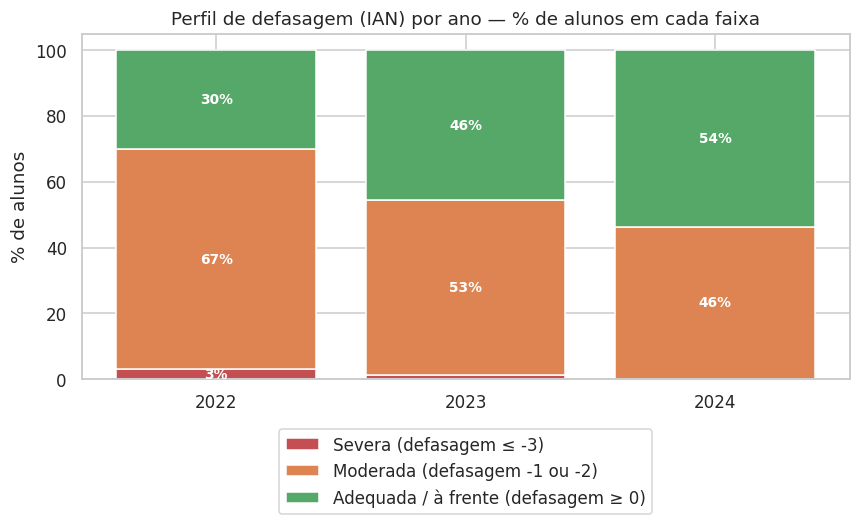

In [10]:
cores_ian = {"Severa (defasagem ≤ -3)": "#c44e52",
             "Moderada (defasagem -1 ou -2)": "#dd8452",
             "Adequada / à frente (defasagem ≥ 0)": "#55a868"}

fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(3)
anos = [2022, 2023, 2024]
for cat in ordem_categorias:
    valores = percentual.loc[anos, cat].values
    ax.bar(anos, valores, bottom=bottom, label=cat, color=cores_ian[cat])
    for i, (v, b) in enumerate(zip(valores, bottom)):
        if v > 3:
            ax.text(anos[i], b + v / 2, f"{v:.0f}%", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    bottom += valores

ax.set_xticks(anos)
ax.set_ylabel("% de alunos")
ax.set_title("Perfil de defasagem (IAN) por ano — % de alunos em cada faixa")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=1)
plt.tight_layout()
plt.show()


**Resposta — Pergunta 1:** em 2022, a maioria dos alunos estava **abaixo do nível ideal**: só
30% tinham defasagem adequada/à frente, e havia 28 alunos (3,3%) em defasagem **severa** (3 fases
ou mais atrás do esperado). Ao longo do ciclo, esse quadro melhora de forma consistente: a fatia
de alunos com nível adequado/à frente sobe para 45,6% em 2023 e 53,8% em 2024, enquanto a
defasagem severa cai para 1,4% e depois para apenas 0,3% (3 alunos) da base. A defasagem
**moderada** (1 ou 2 fases atrás) continua sendo a situação mais comum mesmo em 2024 — ou seja, o
programa parece estar reduzindo os casos mais graves mais rápido do que eliminando a defasagem
como um todo.


## Pergunta 2 — Desempenho acadêmico (IDA)

> *O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e
> anos?*


In [11]:
print("IDA — estatísticas descritivas por ano:")
print(panel.groupby("Ano")["IDA"].describe()[["count", "mean", "std", "50%"]].round(2))


IDA — estatísticas descritivas por ano:
       count  mean   std   50%
Ano                           
2022   860.0  6.09  2.05  6.30
2023   937.0  6.66  1.60  6.80
2024  1055.0  6.35  2.13  6.75


In [12]:
piv_ida = panel.pivot_table(index="Fase_num", columns="Ano", values="IDA", aggfunc="mean")
print("IDA médio por fase e ano:")
print(piv_ida.round(2))


IDA médio por fase e ano:
Ano       2022  2023  2024
Fase_num                  
0         7.14  7.42  7.32
1         6.46  6.81  6.79
2         5.41  6.74  6.25
3         5.14  5.75  5.35
4         6.05  6.00  5.88
5         5.87  5.90  6.45
6         6.69  6.81  7.23
7         5.25  7.81  5.81
8          NaN   NaN  8.00


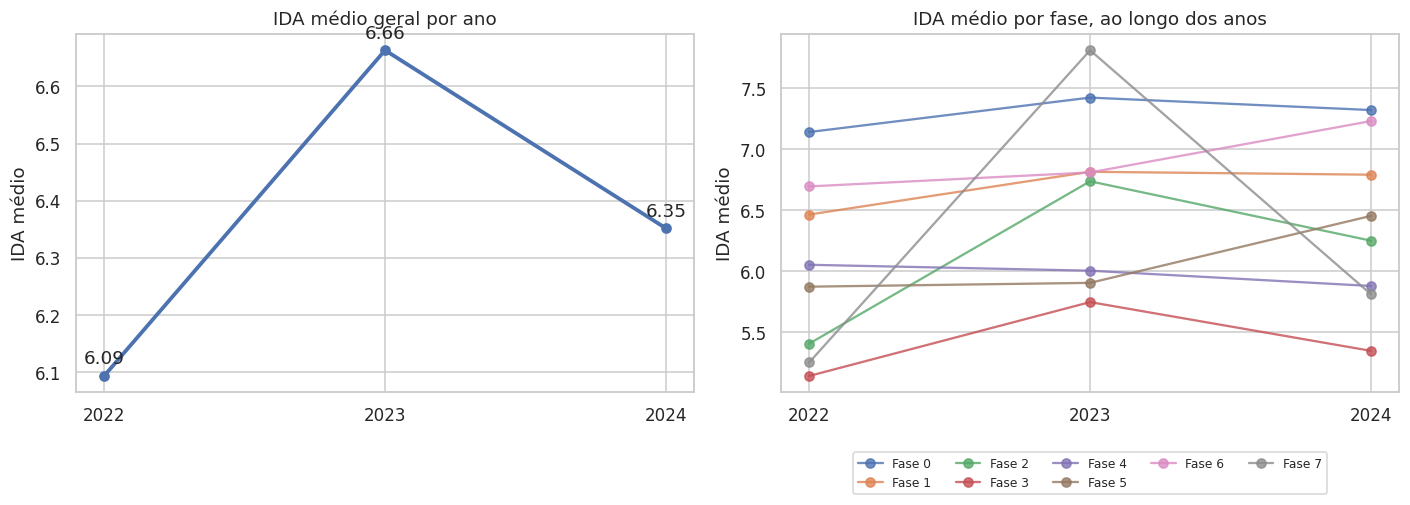

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

anos = [2022, 2023, 2024]
medias = panel.groupby("Ano")["IDA"].mean()
axes[0].plot(anos, medias.values, marker="o", linewidth=2.5, color="#4c72b0")
for a, v in zip(anos, medias.values):
    axes[0].annotate(f"{v:.2f}", (a, v), textcoords="offset points", xytext=(0, 8), ha="center")
axes[0].set_xticks(anos)
axes[0].set_ylabel("IDA médio")
axes[0].set_title("IDA médio geral por ano")

fases_com_dados = piv_ida.dropna(thresh=2).index
for fase in fases_com_dados:
    axes[1].plot(anos, [piv_ida.loc[fase, a] if a in piv_ida.columns else np.nan for a in anos],
                 marker="o", label=f"Fase {int(fase)}", alpha=0.8)
axes[1].set_xticks(anos)
axes[1].set_ylabel("IDA médio")
axes[1].set_title("IDA médio por fase, ao longo dos anos")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=5, fontsize=8)

plt.tight_layout()
plt.show()


**Resposta — Pergunta 2:** no agregado, o IDA médio **melhora** de 2022 (6,09) para 2023 (6,66),
mas recua parcialmente em 2024 (6,35) — ainda assim acima do patamar de 2022. Olhando por fase, o
padrão não é uniforme: fases iniciais (0 e 1) mostram uma trajetória de melhora relativamente
estável nos três anos; fases intermediárias (2, 3) sobem de 2022 para 2023 e depois recuam em
2024; e fases mais avançadas (6, 7) têm mais oscilação — parcialmente porque têm poucos alunos
por fase/ano, o que deixa a média mais sensível a casos individuais. Em suma: o desempenho
acadêmico não é uma linha reta de melhora contínua — teve um salto claro entre 2022 e 2023, seguido
de uma leve acomodação/queda em 2024, sugerindo que vale a pena investigar o que mudou
operacionalmente entre 2023 e 2024 (composição de novos alunos, mudanças pedagógicas, etc.).


## Pergunta 3 — Engajamento nas atividades (IEG)

> *O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho
> (IDA) e do ponto de virada (IPV)?*


In [14]:
print("Correlação entre IEG, IDA e IPV (todos os anos juntos):")
print(panel[["IEG", "IDA", "IPV"]].corr().round(3))
print()
print("Correlação de IEG com IDA e IPV, calculada separadamente por ano:")
for ano in [2022, 2023, 2024]:
    sub = panel[panel["Ano"] == ano]
    corr_ida = sub["IEG"].corr(sub["IDA"])
    corr_ipv = sub["IEG"].corr(sub["IPV"])
    print(f"  {ano}: IEG x IDA = {corr_ida:.3f}  |  IEG x IPV = {corr_ipv:.3f}")


Correlação entre IEG, IDA e IPV (todos os anos juntos):
       IEG    IDA    IPV
IEG  1.000  0.539  0.558
IDA  0.539  1.000  0.557
IPV  0.558  0.557  1.000

Correlação de IEG com IDA e IPV, calculada separadamente por ano:
  2022: IEG x IDA = 0.564  |  IEG x IPV = 0.589
  2023: IEG x IDA = 0.461  |  IEG x IPV = 0.449
  2024: IEG x IDA = 0.538  |  IEG x IPV = 0.535


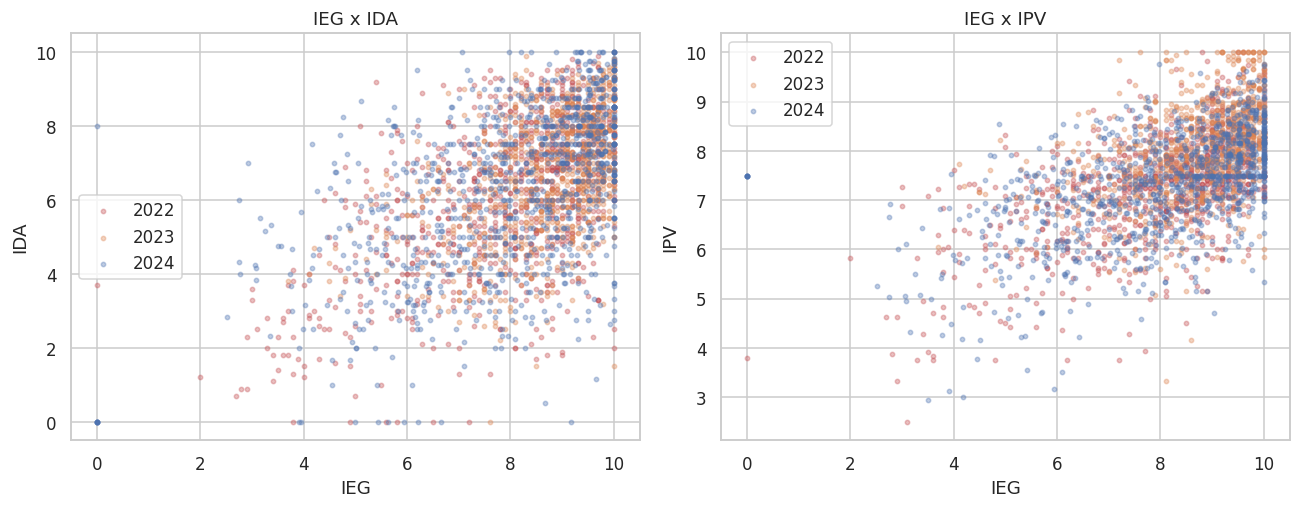

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ano in anos:
    sub = panel[panel["Ano"] == ano]
    axes[0].scatter(sub["IEG"], sub["IDA"], s=8, alpha=0.35, color=CORES_ANO[ano], label=str(ano))
    axes[1].scatter(sub["IEG"], sub["IPV"], s=8, alpha=0.35, color=CORES_ANO[ano], label=str(ano))
axes[0].set_xlabel("IEG"); axes[0].set_ylabel("IDA"); axes[0].set_title("IEG x IDA")
axes[1].set_xlabel("IEG"); axes[1].set_ylabel("IPV"); axes[1].set_title("IEG x IPV")
axes[0].legend(); axes[1].legend()
plt.tight_layout()
plt.show()


**Resposta — Pergunta 3:** sim, há uma relação direta e consistente: a correlação de IEG com IDA
é de 0,54 e com IPV é de 0,56 (considerando os três anos juntos), e o padrão se mantém em todos
os anos individualmente (correlações entre 0,45 e 0,59). Ou seja, quanto mais engajado o aluno
está nas atividades, mais alto tende a ser tanto seu desempenho acadêmico quanto sua proximidade
do "ponto de virada". A relação é positiva e de magnitude moderada — forte o suficiente para ser
um sinal relevante, mas não determinística: existem alunos engajados com desempenho mediano e
vice-versa, o que reforça a ideia de que IDA e IPV são conceitos multidimensionais (voltamos a
esse ponto na Pergunta 8).


## Pergunta 4 — Autoavaliação (IAA)

> *As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e
> engajamento (IEG)?*


In [16]:
print("Correlação entre IAA, IDA e IEG:")
print(panel[["IAA", "IDA", "IEG"]].corr().round(3))
print()
print("IAA — estatísticas descritivas:")
print(panel["IAA"].describe().round(2))
print()
print("% de registros com IAA = 0 (provável não resposta), por ano:")
print((panel.groupby("Ano")["IAA"].apply(lambda s: (s == 0).mean() * 100)).round(1))


Correlação entre IAA, IDA e IEG:
       IAA    IDA    IEG
IAA  1.000  0.115  0.133
IDA  0.115  1.000  0.539
IEG  0.133  0.539  1.000

IAA — estatísticas descritivas:
count    2865.00
mean        7.92
std         2.63
min         0.00
25%         7.90
50%         8.75
75%         9.50
max        10.00
Name: IAA, dtype: float64

% de registros com IAA = 0 (provável não resposta), por ano:
Ano
2022     4.5
2023    18.7
2024     1.7
Name: IAA, dtype: float64


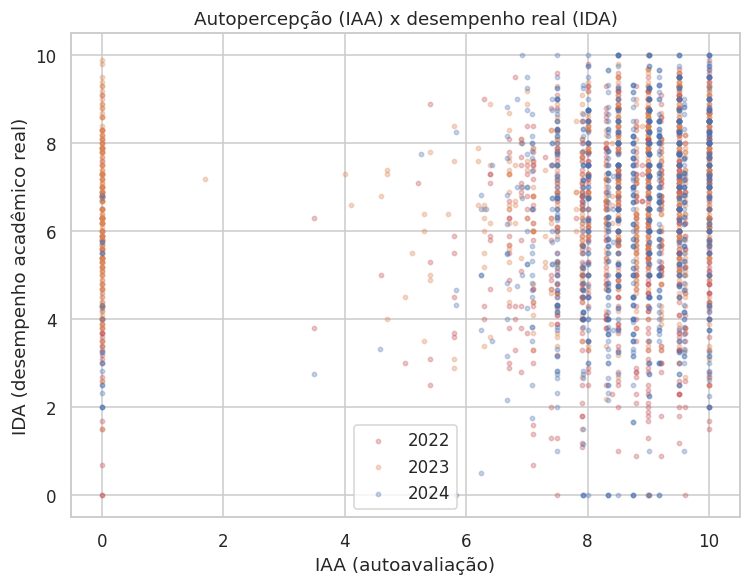

In [17]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sub = panel.dropna(subset=["IAA", "IDA"])
for ano in anos:
    s = sub[sub["Ano"] == ano]
    ax.scatter(s["IAA"], s["IDA"], s=8, alpha=0.3, color=CORES_ANO[ano], label=str(ano))
ax.set_xlabel("IAA (autoavaliação)")
ax.set_ylabel("IDA (desempenho acadêmico real)")
ax.set_title("Autopercepção (IAA) x desempenho real (IDA)")
ax.legend()
plt.tight_layout()
plt.show()


**Resposta — Pergunta 4:** não muito. A correlação do IAA com o IDA é de apenas 0,12, e com o
IEG é de 0,13 — bem mais fraca do que, por exemplo, a relação entre IEG e IDA vista na Pergunta 3.
O gráfico de dispersão reforça isso: a nuvem de pontos é bastante espalhada, sem uma tendência
clara — há muitos alunos com autoavaliação alta (IAA perto de 9–10) espalhados por todo o
espectro de desempenho real, inclusive entre os que têm IDA baixo. Isso sugere que a
**autopercepção dos alunos não é um bom proxy do desempenho real**: vale a pena a equipe
pedagógica tratar o IAA como uma medida de autoestima/confiança, e não como um substituto de
avaliação de desempenho. Um cuidado adicional: cerca de 8% dos registros têm IAA = 0 (mais
concentrados em 2023, com quase 19%), provavelmente alunos que não responderam à autoavaliação —
o que reforça que o indicador tem limitações de cobertura, além da baixa correlação com o
desempenho real.


## Pergunta 5 — Aspectos psicossociais (IPS)

> *Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de
> engajamento?*

Para responder isso de verdade precisamos olhar a **trajetória** de cada aluno, não só a
fotografia de um ano: pegamos o IPS de um aluno no ano `t` e comparamos com a **variação** (Δ) de
IDA e de IEG desse mesmo aluno no ano seguinte (`t+1`). Isso usa a mesma lógica longitudinal que
será formalizada na Parte 2 (Pergunta 9), mas aqui de forma simplificada, focada só no IPS.


In [18]:
base_ips = panel[["RA", "Ano", "IPS", "IDA", "IEG"]].copy()

def transicoes_ips(base, t):
    t1 = t + 1
    a = base[base["Ano"] == t].drop(columns=["Ano"]).add_suffix("_t").rename(columns={"RA_t": "RA"})
    b = base[base["Ano"] == t1][["RA", "IDA", "IEG"]].rename(columns={"IDA": "IDA_t1", "IEG": "IEG_t1"})
    m = a.merge(b, on="RA", how="inner")
    m["delta_IDA"] = m["IDA_t1"] - m["IDA_t"]
    m["delta_IEG"] = m["IEG_t1"] - m["IEG_t"]
    return m

trans_ips = pd.concat([transicoes_ips(base_ips, 2022), transicoes_ips(base_ips, 2023)], ignore_index=True)
print("Transições ano-a-ano disponíveis para essa análise:", trans_ips.shape[0], "alunos")
print()
print("Correlação entre IPS no ano t e a variação de IDA/IEG no ano t+1:")
print(trans_ips[["IPS_t", "delta_IDA", "delta_IEG"]].corr().round(3)[["delta_IDA", "delta_IEG"]].loc[["IPS_t"]])


Transições ano-a-ano disponíveis para essa análise: 1365 alunos

Correlação entre IPS no ano t e a variação de IDA/IEG no ano t+1:
       delta_IDA  delta_IEG
IPS_t       0.12      0.161


In [19]:
limiar_ips_baixo = trans_ips["IPS_t"].quantile(0.20)
trans_ips["Grupo_IPS"] = np.where(trans_ips["IPS_t"] <= limiar_ips_baixo,
                                   f"IPS baixo (≤ {limiar_ips_baixo:.1f}, 20% inferior)",
                                   "Demais alunos")

resumo_ips = trans_ips.groupby("Grupo_IPS")[["delta_IDA", "delta_IEG"]].mean()
print("Variação média de IDA e IEG no ano seguinte, por grupo de IPS:")
print(resumo_ips.round(3))


Variação média de IDA e IEG no ano seguinte, por grupo de IPS:
                                 delta_IDA  delta_IEG
Grupo_IPS                                            
Demais alunos                       -0.102     -0.296
IPS baixo (≤ 3.8, 20% inferior)     -0.584     -0.829


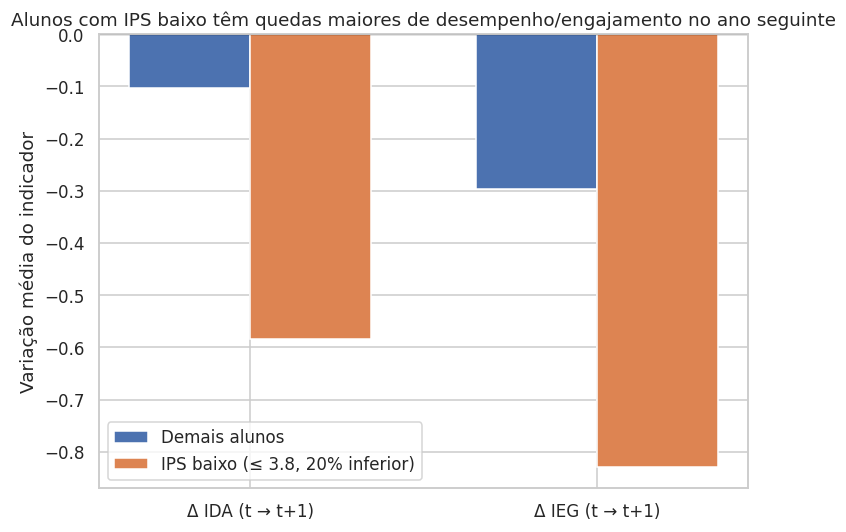

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
largura = 0.35
grupos = resumo_ips.index.tolist()
for i, grupo in enumerate(grupos):
    valores = resumo_ips.loc[grupo, ["delta_IDA", "delta_IEG"]].values
    ax.bar(x + i * largura, valores, largura, label=grupo)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x + largura / 2)
ax.set_xticklabels(["Δ IDA (t → t+1)", "Δ IEG (t → t+1)"])
ax.set_ylabel("Variação média do indicador")
ax.set_title("Alunos com IPS baixo têm quedas maiores de desempenho/engajamento no ano seguinte")
ax.legend()
plt.tight_layout()
plt.show()


**Resposta — Pergunta 5:** sim, há um padrão consistente, embora de magnitude moderada. Alunos
no grupo de IPS mais baixo (20% inferior) apresentam, no ano seguinte, uma queda média de IDA
mais de 5x maior (-0,58 vs -0,10) e de IEG quase 3x maior (-0,83 vs -0,30) do que o restante dos
alunos. Ou seja, o aspecto psicossocial parece funcionar como um **sinal de alerta antecipado**:
mesmo sem olhar o desempenho futuro, um IPS baixo hoje está associado a uma deterioração maior de
desempenho e engajamento amanhã.

**Ressalva importante:** ao explorar o IPS por ano isoladamente (não mostrado no gráfico acima),
a média de 2023 (5,1) é visivelmente mais baixa do que 2022 e 2024 (ambos por volta de 6,8–6,9),
enquanto o IDA e o IEG não mostram essa mesma queda abrupta em 2023. Isso é mais coerente com uma
possível mudança de escala/metodologia na pesquisa psicossocial daquele ano específico do que com
uma piora psicossocial real e isolada da turma inteira — um cuidado que vale levar para a equipe
responsável pela pesquisa, para não confundir mudança de instrumento com mudança de população.


## Pergunta 6 — Aspectos psicopedagógicos (IPP)

> *As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo
> IAN?*

O IPP só está disponível a partir de 2023 (não existe na aba de 2022), então essa análise cobre
2023 e 2024.


In [21]:
sub_ipp = panel.dropna(subset=["IPP"]).copy()
print(f"Registros com IPP preenchido: {len(sub_ipp)} de {len(panel)} ({len(sub_ipp)/len(panel):.1%})")
print()
print("IPP médio por ano:")
print(sub_ipp.groupby("Ano")["IPP"].mean().round(2))
print()
print("Correlação IPP x IAN x Defasagem:")
print(sub_ipp[["IPP", "IAN", "Defasagem"]].corr().round(3))


Registros com IPP preenchido: 1992 de 3030 (65.7%)

IPP médio por ano:
Ano
2023    7.56
2024    7.55
Name: IPP, dtype: float64

Correlação IPP x IAN x Defasagem:
             IPP    IAN  Defasagem
IPP        1.000  0.123      0.182
IAN        0.123  1.000      0.855
Defasagem  0.182  0.855      1.000


IPP médio por faixa de defasagem (IAN):
Defasagem
Severa (≤ -3)          7.01
Moderada (-1 ou -2)    7.46
Nenhuma (0)            7.64
Adiantado (> 0)        7.93
Name: IPP, dtype: float64


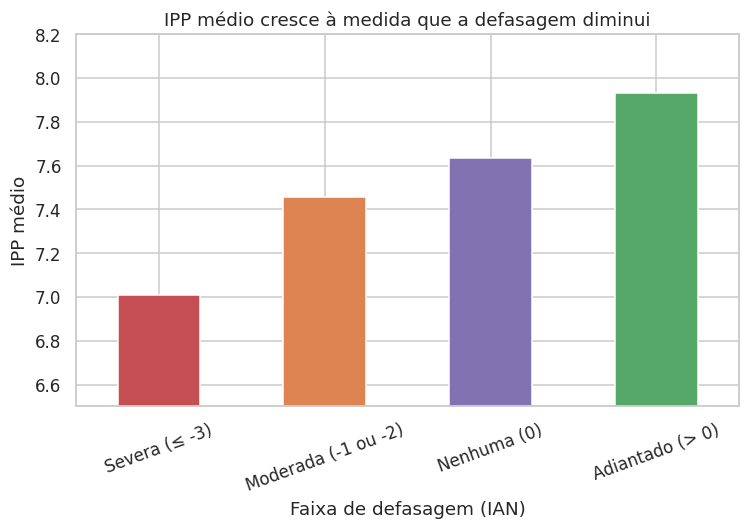

In [22]:
faixas_defas = pd.cut(sub_ipp["Defasagem"], bins=[-6, -3, -1, 0, 10],
                       labels=["Severa (≤ -3)", "Moderada (-1 ou -2)", "Nenhuma (0)", "Adiantado (> 0)"])
media_ipp_por_faixa = sub_ipp.groupby(faixas_defas)["IPP"].mean()
print("IPP médio por faixa de defasagem (IAN):")
print(media_ipp_por_faixa.round(2))

fig, ax = plt.subplots(figsize=(7, 5))
media_ipp_por_faixa.plot(kind="bar", ax=ax, color=["#c44e52", "#dd8452", "#8172b2", "#55a868"])
ax.set_ylabel("IPP médio")
ax.set_xlabel("Faixa de defasagem (IAN)")
ax.set_title("IPP médio cresce à medida que a defasagem diminui")
ax.set_ylim(6.5, 8.2)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Resposta — Pergunta 6:** o IPP **confirma parcialmente**, mas com concordância fraca. Há uma
tendência clara e monotônica na direção esperada — quanto mais severa a defasagem, menor o IPP
médio (7,01 na defasagem severa vs 7,93 nos alunos adiantados) — mas a correlação direta entre
IPP e Defasagem é de apenas 0,18 (e com o IAN, 0,12). Isso quer dizer que a avaliação
psicopedagógica **não é redundante** com o IAN: ela capta uma dimensão distinta do
desenvolvimento do aluno (mais qualitativa, sobre processos de aprendizagem) que só se relaciona
fracamente com a métrica objetiva de fase/idade. Na prática, isso é uma boa notícia para o
programa: o IPP pode identificar alunos com dificuldades de aprendizagem que ainda não apareceram
como defasagem de fase (ou vice-versa, alunos defasados de fase mas sem sinais psicopedagógicos
graves) — os dois indicadores se complementam mais do que se confirmam.


## Pergunta 7 — Ponto de virada (IPV)

> *Quais comportamentos — acadêmicos, emocionais ou de engajamento — mais influenciam o IPV ao
> longo do tempo?*


In [23]:
colunas_indicadores = ["IAA", "IEG", "IPS", "IPP", "IDA", "INDE"]
corr_ipv = panel[colunas_indicadores + ["IPV"]].corr()["IPV"].drop("IPV").sort_values(ascending=False)
print("Correlação de cada indicador com o IPV:")
print(corr_ipv.round(3))


Correlação de cada indicador com o IPV:
INDE    0.721
IPP     0.607
IEG     0.558
IDA     0.557
IAA     0.063
IPS    -0.049
Name: IPV, dtype: float64


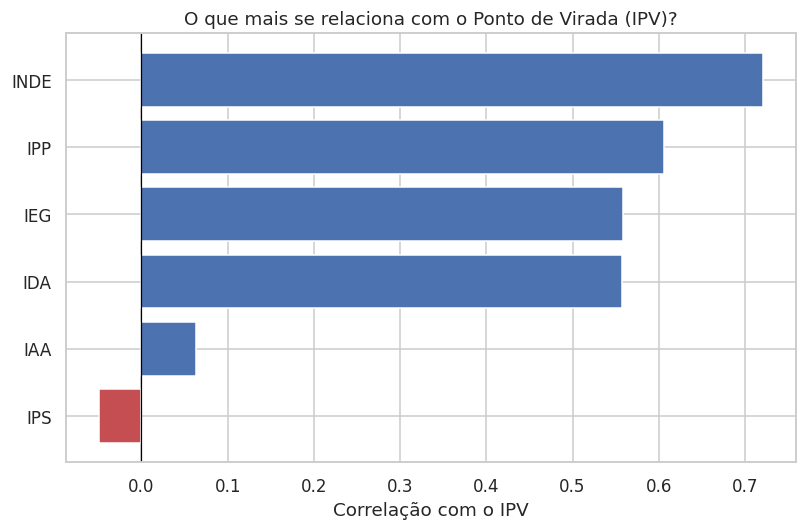

In [24]:
fig, ax = plt.subplots(figsize=(7.5, 5))
cores_barra = ["#4c72b0" if v >= 0 else "#c44e52" for v in corr_ipv.values]
ax.barh(corr_ipv.index[::-1], corr_ipv.values[::-1], color=cores_barra[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlação com o IPV")
ax.set_title("O que mais se relaciona com o Ponto de Virada (IPV)?")
plt.tight_layout()
plt.show()


In [25]:
print("Alunos que efetivamente atingiram o Ponto de Virada — comparação de indicadores (dado disponível só em 2022):")
print(panel.groupby("Atingiu_PV")[["IAA", "IEG", "IPS", "IDA"]].mean().round(2))
print()
print("Contagem:")
print(panel["Atingiu_PV"].value_counts(dropna=False))


Alunos que efetivamente atingiram o Ponto de Virada — comparação de indicadores (dado disponível só em 2022):
             IAA   IEG   IPS   IDA
Atingiu_PV                        
Não         8.18  7.72  6.84  5.82
Sim         8.87  9.01  7.32  7.87

Contagem:
Atingiu_PV
NaN    2170
Não     747
Sim     113
Name: count, dtype: int64


**Resposta — Pergunta 7:** os comportamentos **acadêmicos e de engajamento** são os que mais
influenciam o IPV — não os emocionais/psicossociais. O INDE (0,72) e o IPP (0,61) têm a
correlação mais forte com o IPV, seguidos de perto por IEG (0,56) e IDA (0,56). Já IAA (0,06) e
IPS (-0,05) têm correlação praticamente nula com o IPV. O recorte dos alunos que **de fato
atingiram** o ponto de virada em 2022 confirma o mesmo padrão: esse grupo tem IEG médio bem mais
alto (9,01 vs 7,72) e IDA mais alto (7,87 vs 5,82) do que quem não atingiu, com uma diferença de
IAA bem menor proporcionalmente. Em resumo: o "salto" que caracteriza o ponto de virada parece
ser puxado por **desempenho acadêmico consistente e engajamento nas atividades**, mais do que por
autoestima ou aspectos psicossociais isolados — o que é um direcionamento útil para a equipe
pedagógica: investir em engajamento/rotina de estudo tende a ter efeito maior no IPV do que
trabalhar isoladamente a autopercepção do aluno.


## Pergunta 8 — Multidimensionalidade dos indicadores

> *Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno
> (INDE)?*

Primeiro olhamos a correlação simples de cada indicador com o INDE; depois, para entender o peso
**relativo** de cada um controlando pelos demais (evitando dupla-contagem entre indicadores
correlacionados entre si), ajustamos uma regressão linear com todos os indicadores padronizados
(média 0, desvio-padrão 1) prevendo o INDE.


In [26]:
colunas_multidim = ["IAA", "IEG", "IPS", "IPP", "IDA", "IPV"]
corr_inde = panel[colunas_multidim + ["INDE"]].corr()["INDE"].drop("INDE").sort_values(ascending=False)
print("Correlação simples de cada indicador com o INDE:")
print(corr_inde.round(3))


Correlação simples de cada indicador com o INDE:
IDA    0.785
IEG    0.745
IPV    0.721
IPP    0.540
IAA    0.397
IPS    0.200
Name: INDE, dtype: float64


In [27]:
sub_multidim = panel.dropna(subset=colunas_multidim + ["INDE"])
X = (sub_multidim[colunas_multidim] - sub_multidim[colunas_multidim].mean()) / sub_multidim[colunas_multidim].std()
y = sub_multidim["INDE"]

reg = LinearRegression().fit(X, y)
pesos = pd.Series(reg.coef_, index=colunas_multidim).sort_values(ascending=False)

print(f"Regressão linear padronizada (n = {len(sub_multidim)} registros com todos os indicadores preenchidos)")
print(f"R² do modelo: {reg.score(X, y):.3f}")
print()
print("Peso relativo de cada indicador sobre o INDE (coeficiente padronizado):")
print(pesos.round(3))


Regressão linear padronizada (n = 1985 registros com todos os indicadores preenchidos)
R² do modelo: 0.933

Peso relativo de cada indicador sobre o INDE (coeficiente padronizado):
IDA    0.383
IEG    0.308
IAA    0.291
IPV    0.232
IPS    0.208
IPP    0.109
dtype: float64


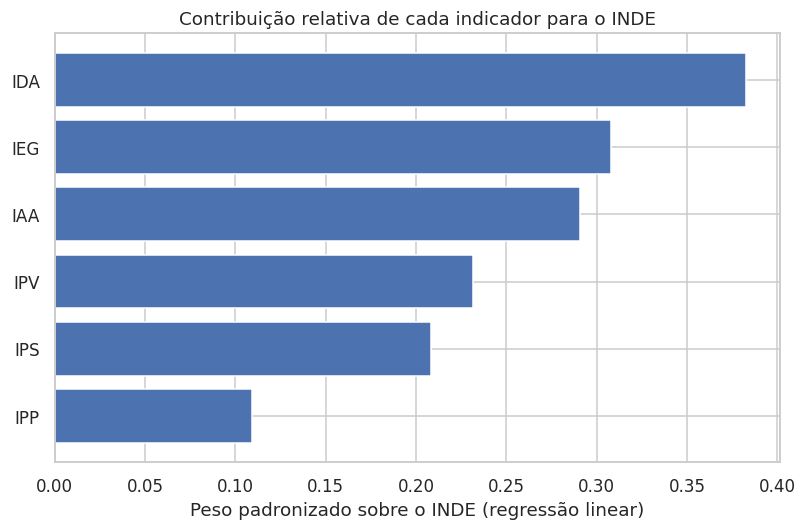

In [28]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(pesos.index[::-1], pesos.values[::-1], color="#4c72b0")
ax.set_xlabel("Peso padronizado sobre o INDE (regressão linear)")
ax.set_title("Contribuição relativa de cada indicador para o INDE")
plt.tight_layout()
plt.show()


**Resposta — Pergunta 8:** o INDE é quase totalmente explicado pela combinação desses seis
indicadores (R² = 0,93), o que já confirma que ele é, por construção, uma síntese
multidimensional. Olhando o peso relativo de cada um: **IDA** (0,38) é o maior contribuinte
isolado, seguido por **IEG** (0,31), **IAA** (0,29), **IPV** (0,23), **IPS** (0,21) e **IPP**
(0,11 — o menor peso, mas ainda positivo). Isso muda um pouco o quadro da correlação simples (onde
IAA aparecia com peso menor): quando se controla pelos demais indicadores, a autoavaliação
recupera importância, sugerindo que ela captura uma variação do INDE que os outros indicadores
não capturam sozinhos — mesmo não tendo, como vimos na Pergunta 4, relação direta com o
desempenho real. Na prática, isso indica que **a combinação que mais eleva o INDE é desempenho
acadêmico forte (IDA) associado a alto engajamento (IEG)** — as duas maiores alavancas — com
ganhos adicionais, ainda que menores, vindos de uma autoimagem positiva (IAA) e de bons
indicadores psicossociais (IPS) e psicopedagógicos (IPP). Nenhum indicador isolado é suficiente:
o modelo com todos juntos explica muito mais variância do que qualquer um sozinho.


## Parte 2 — Pergunta 9: previsão de risco com Machine Learning

> *Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no
> desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade
> do aluno ou aluna entrar em risco de defasagem.*

### Estratégia geral

A base traz **3 fotografias anuais** do PEDE (2022, 2023 e 2024), com um número relevante de
alunos em comum entre os anos (visto na seção 0.4). Em vez de tratar cada ano como uma amostra
independente, vamos montar um **painel longitudinal por aluno (RA)** e transformar o problema em
uma pergunta genuinamente preditiva:

> Dados os indicadores do aluno **no ano corrente (t)**, qual a probabilidade de ele estar
> **defasado no ano seguinte (t+1)**?

Essa escolha evita **vazamento de dados (data leakage)** — o erro mais comum nesse tipo de
problema — porque o modelo nunca vê, para nenhum aluno, informação do próprio ano que está
tentando prever.

O restante desta parte segue as etapas pedidas: **feature engineering → separação treino/teste →
modelagem → avaliação dos resultados**, e termina com uma aplicação prática: uma lista priorizada
dos alunos da coorte 2024 com maior probabilidade de risco no próximo ciclo.

### Por que não usar IDA/IEG/IPS do mesmo ano

Uma armadilha comum é treinar um modelo para prever `RiscoDefasagem` usando indicadores **do
mesmo ano**. Isso não é tecnicamente "vazamento" no sentido estrito, mas é uma **pergunta de
negócio diferente e menos útil**: descreve a situação atual do aluno, e não antecipa o futuro.

Vale lembrar também o achado da Pergunta 1: o **IAN** é, na prática, uma **função em degraus da
própria `Defasagem`** do mesmo ano — os dois carregam quase a mesma informação, então não faz
sentido usá-los como *preditores redundantes* do mesmo ano no modelo.


### Feature engineering

Com o painel limpo, criamos os atributos que alimentarão o modelo — todos calculados **a partir
do ano corrente (t)**, nunca do ano-alvo:

- **`Anos_na_PM`** = tempo de programa (`Ano` − `Ano_ingresso`), um proxy de "dose" de
  intervenção recebida.
- **`Pedra_ordinal`** = codificação ordinal de `Pedra` (Quartzo < Ágata < Ametista < Topázio),
  em vez de one-hot, já que existe uma ordem natural entre as pedras.
- **`Instituicao_grp`** = agrupamento de `Instituição de ensino` em `Pública` / `Privada` /
  `Concluiu/Universitário` / `Outra`, já que o texto bruto varia entre anos (ex.: `"Escola
  Pública"` vs `"Pública"`).

Também decidimos, conscientemente, **não usar** algumas colunas no modelo:

- `Nota_Ing` (inglês): preenchimento parcial e inconsistente entre anos — ruído demais.
- `Cg`/`Cf`/`Ct` (rankings), `Indicado` (indicação de bolsa), `Atingiu PV` e as colunas `Rec
  Av1-4`: existem **preenchidas apenas na aba de 2022** — nas abas de 2023 e 2024 essas colunas
  existem no cabeçalho, mas vêm **100% vazias**. Usá-las geraria um atributo que na prática só
  teria sinal para uma das duas coortes de transição.


In [29]:
panel["Anos_na_PM"] = panel["Ano"] - panel["Ano_ingresso"]

pedra_map = {"Quartzo": 1, "Ágata": 2, "Ametista": 3, "Topázio": 4}
panel["Pedra_ordinal"] = panel["Pedra"].map(pedra_map)

def group_instituicao(s):
    if pd.isna(s):
        return "Outra/NI"
    s_low = str(s).lower()
    if "públic" in s_low or "publica" in s_low:
        return "Pública"
    if "privada" in s_low:
        return "Privada"
    if "concluiu" in s_low or "universit" in s_low:
        return "Concluiu/Universitário"
    return "Outra/NI"

panel["Instituicao_grp"] = panel["Instituicao"].apply(group_instituicao)

feature_cols = ["Fase_num", "Idade", "Anos_na_PM", "Genero", "Instituicao_grp", "Pedra_ordinal",
                "INDE", "IAA", "IEG", "IPS", "IPP", "IDA", "Nota_Mat", "Nota_Por", "IPV", "Defasagem"]

print("% de preenchimento de cada atributo candidato, por ano:")
print((panel.groupby("Ano")[feature_cols].apply(lambda g: g.notnull().mean()) * 100).round(1))


% de preenchimento de cada atributo candidato, por ano:
      Fase_num  Idade  Anos_na_PM  Genero  Instituicao_grp  Pedra_ordinal  \
Ano                                                                         
2022     100.0  100.0       100.0   100.0            100.0          100.0   
2023     100.0  100.0       100.0   100.0            100.0           91.8   
2024     100.0  100.0       100.0   100.0            100.0           91.2   

       INDE    IAA    IEG    IPS   IPP    IDA  Nota_Mat  Nota_Por    IPV  \
Ano                                                                        
2022  100.0  100.0  100.0  100.0   0.0  100.0      99.8      99.8  100.0   
2023   91.8   93.8   92.5   93.2  92.5   92.4      92.4      92.4   92.5   
2024   91.2   91.2  100.0   91.2  91.2   91.3      90.9      90.8   91.2   

      Defasagem  
Ano              
2022      100.0  
2023      100.0  
2024      100.0  


### Construindo o dataset de transições (t → t+1) e o alvo

Para cada par de anos consecutivos com alunos em comum (**2022→2023** e **2023→2024**),
cruzamos os atributos do ano `t` com a `Defasagem` observada no ano `t+1`. O alvo binário é:

$$\text{Em\_Risco\_Defasagem\_t1} = 1 \iff \text{Defasagem}_{t+1} < 0$$

(ou seja, o aluno está **abaixo do nível ideal** no ano seguinte). Empilhamos as duas transições
em um único dataset de modelagem — isso também aumenta o volume de dados de treino.


In [30]:
base = panel[["RA", "Ano"] + feature_cols].copy()

def build_transitions(base, t):
    t1 = t + 1
    df_t = base[base["Ano"] == t].drop(columns=["Ano"]).add_suffix("_t").rename(columns={"RA_t": "RA"})
    df_t1 = base[base["Ano"] == t1][["RA", "Defasagem"]].rename(columns={"Defasagem": "Defasagem_t1"})
    merged = df_t.merge(df_t1, on="RA", how="inner")
    merged["Ano_t"] = t
    return merged

trans_22_23 = build_transitions(base, 2022)
trans_23_24 = build_transitions(base, 2023)

modelo_df = pd.concat([trans_22_23, trans_23_24], ignore_index=True)
modelo_df["Em_Risco_Defasagem_t1"] = (modelo_df["Defasagem_t1"] < 0).astype(int)
modelo_df["IPP_disponivel_t"] = modelo_df["IPP_t"].notnull().astype(int)

print("Transições 2022→2023:", trans_22_23.shape[0], "alunos")
print("Transições 2023→2024:", trans_23_24.shape[0], "alunos")
print("Dataset de modelagem final:", modelo_df.shape)
print("Alunos únicos (algumas linhas repetem RA, uma por transição):", modelo_df['RA'].nunique())
print()
print("Prevalência do alvo por coorte de transição:")
print(modelo_df.groupby("Ano_t")["Em_Risco_Defasagem_t1"].mean().rename("proporção em risco no ano seguinte"))


Transições 2022→2023: 600 alunos
Transições 2023→2024: 765 alunos
Dataset de modelagem final: (1365, 21)
Alunos únicos (algumas linhas repetem RA, uma por transição): 897

Prevalência do alvo por coorte de transição:
Ano_t
2022    0.610000
2023    0.402614
Name: proporção em risco no ano seguinte, dtype: float64


> **Achado interessante (conecta com a Pergunta 10 — efetividade do programa):** a proporção
> de alunos que acabam defasados no ano seguinte **cai de ~61% (coorte 2022→2023) para ~40%
> (coorte 2023→2024)**. Isso é evidência adicional, independente da análise por fase/pedra, de que
> a taxa de risco de defasagem vem diminuindo ao longo dos ciclos do programa.

### Separação treino/teste — cuidado com vazamento de aluno

Como o mesmo aluno pode contribuir com **duas linhas** (uma por transição, se ele aparece nos 3
anos), um `train_test_split` comum poderia colocar a transição 2022→2023 de um aluno no treino e a
2023→2024 do **mesmo aluno** no teste — vazando informação sobre ele entre os conjuntos. Usamos
`GroupShuffleSplit` agrupando por `RA`, garantindo que cada aluno fique **inteiramente** em treino
ou em teste.


In [31]:
numeric_features = ["Fase_num_t", "Idade_t", "Anos_na_PM_t", "Pedra_ordinal_t", "INDE_t", "IAA_t",
                     "IEG_t", "IPS_t", "IPP_t", "IDA_t", "Nota_Mat_t", "Nota_Por_t", "IPV_t",
                     "Defasagem_t", "IPP_disponivel_t"]
categorical_features = ["Genero_t", "Instituicao_grp_t", "Ano_t"]

X = modelo_df[numeric_features + categorical_features].copy()
X["Ano_t"] = X["Ano_t"].astype(str)
y = modelo_df["Em_Risco_Defasagem_t1"]
groups = modelo_df["RA"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print(f"Treino: {X_train.shape[0]} linhas | Teste: {X_test.shape[0]} linhas")
print(f"Alunos (RA) presentes em treino E teste ao mesmo tempo: {len(overlap)}  (precisa ser 0)")
print(f"Prevalência do alvo — treino: {y_train.mean():.1%} | teste: {y_test.mean():.1%}")


Treino: 1012 linhas | Teste: 353 linhas
Alunos (RA) presentes em treino E teste ao mesmo tempo: 0  (precisa ser 0)
Prevalência do alvo — treino: 49.9% | teste: 47.9%


### Pré-processamento e modelagem

Pipeline de pré-processamento:
- **Numéricas:** imputação pela mediana + padronização (`StandardScaler`).
- **Categóricas:** imputação pela moda + `OneHotEncoder`.

Testamos dois modelos:
- **Regressão Logística** (`class_weight="balanced"`) — baseline simples e interpretável.
- **Random Forest** — captura não linearidades e interações entre indicadores.


In [32]:
preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                       ("scaler", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features)
])

modelos = {
    "Regressão Logística": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=5,
                                             class_weight="balanced", random_state=42)
}

pipelines = {}
resultados = {}

for nome, clf in modelos.items():
    pipe = Pipeline([("prep", preprocess), ("clf", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    pipelines[nome] = pipe
    resultados[nome] = {"y_pred": y_pred, "y_proba": y_proba}

    print("=" * 72)
    print(nome)
    print(classification_report(y_test, y_pred, target_names=["Sem risco", "Em risco"]))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3),
          "| PR-AUC:", round(average_precision_score(y_test, y_proba), 3))


Regressão Logística
              precision    recall  f1-score   support

   Sem risco       0.77      0.78      0.78       184
    Em risco       0.76      0.75      0.75       169

    accuracy                           0.76       353
   macro avg       0.76      0.76      0.76       353
weighted avg       0.76      0.76      0.76       353

ROC-AUC: 0.871 | PR-AUC: 0.872
Random Forest
              precision    recall  f1-score   support

   Sem risco       0.81      0.80      0.81       184
    Em risco       0.79      0.80      0.79       169

    accuracy                           0.80       353
   macro avg       0.80      0.80      0.80       353
weighted avg       0.80      0.80      0.80       353

ROC-AUC: 0.898 | PR-AUC: 0.889


### Avaliação visual: matrizes de confusão e curva ROC

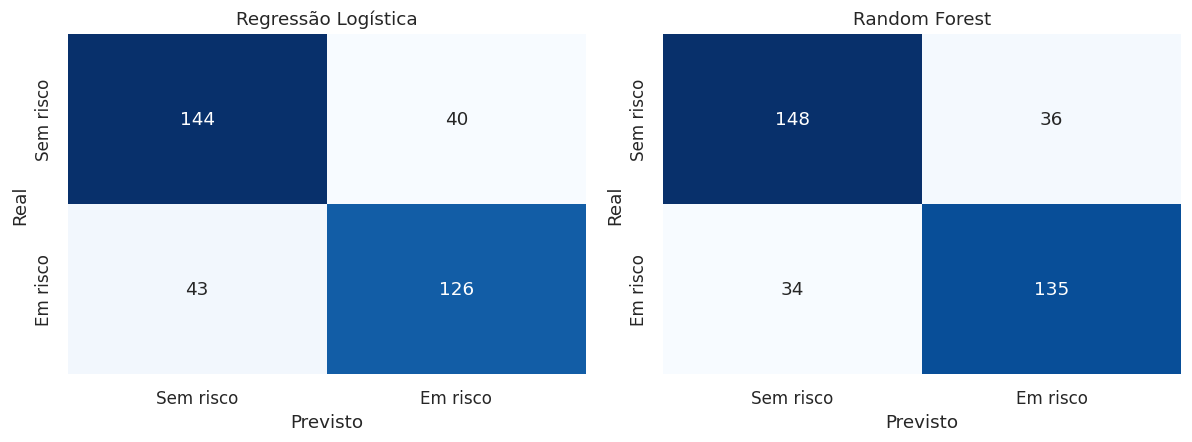

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (nome, res) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Sem risco", "Em risco"], yticklabels=["Sem risco", "Em risco"])
    ax.set_title(nome)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()


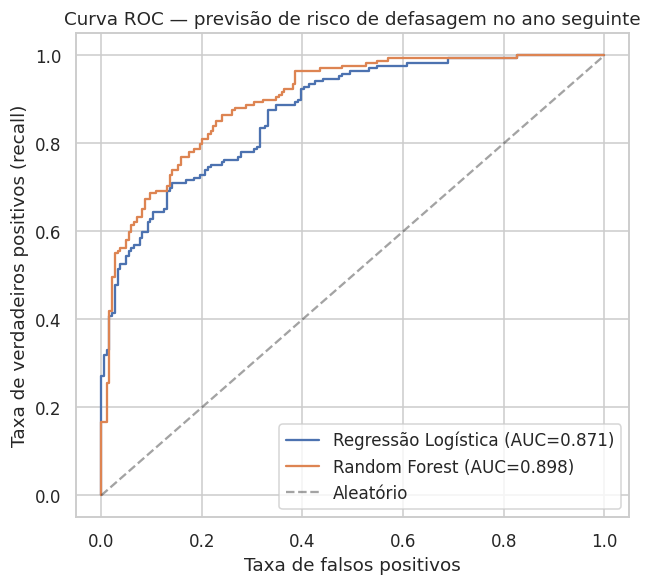

In [34]:
plt.figure(figsize=(6, 5.5))
for nome, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    auc = roc_auc_score(y_test, res["y_proba"])
    plt.plot(fpr, tpr, label=f"{nome} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Aleatório")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos (recall)")
plt.title("Curva ROC — previsão de risco de defasagem no ano seguinte")
plt.legend()
plt.tight_layout()
plt.show()


**Leitura dos resultados:** os dois modelos têm desempenho bom para um problema social real
(ROC-AUC ~0,87–0,90), com precisão e recall próximos de 0,80 para a classe "em risco" — ou seja, o
modelo erra pouco tanto ao apontar falsos alarmes quanto ao deixar passar alunos que de fato
entrarão em defasagem. O **Random Forest** tem uma pequena vantagem em todas as métricas e será o
modelo escolhido para as próximas seções.

### O que mais pesa na previsão? (importância dos atributos)


num__Defasagem_t                  0.159037
num__IPV_t                        0.122766
num__Fase_num_t                   0.116633
num__INDE_t                       0.101204
num__Idade_t                      0.081485
num__IPP_t                        0.058514
num__Nota_Por_t                   0.045199
num__IDA_t                        0.042823
cat__Instituicao_grp_t_Pública    0.037108
num__IEG_t                        0.036376
num__Pedra_ordinal_t              0.035413
num__Nota_Mat_t                   0.032985
dtype: float64


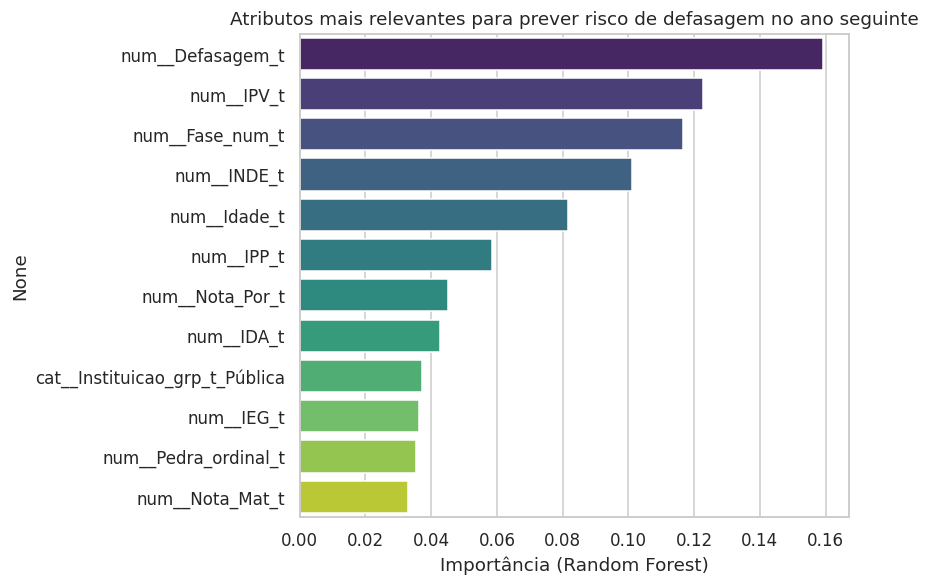

In [35]:
modelo_final_nome = "Random Forest"
pipe_final = pipelines[modelo_final_nome]

feat_names = pipe_final.named_steps["prep"].get_feature_names_out()
importancias = pd.Series(pipe_final.named_steps["clf"].feature_importances_, index=feat_names)
importancias = importancias.sort_values(ascending=False).head(12)

plt.figure(figsize=(8, 5.5))
sns.barplot(x=importancias.values, y=importancias.index, palette="viridis")
plt.xlabel("Importância (Random Forest)")
plt.title("Atributos mais relevantes para prever risco de defasagem no ano seguinte")
plt.tight_layout()
plt.show()

print(importancias)


**Leitura:** a defasagem **atual** (`Defasagem_t`) e o ponto de virada (`IPV_t`) são os
sinais mais fortes — ou seja, defasagem tende a **persistir** se nada muda, e o quanto o aluno já
está perto do seu "ponto de virada" ajuda a prever o próximo ano. `Fase_num_t` e `INDE_t` também
pesam bastante: alunos em fases mais avançadas e com nota global mais alta têm menor risco. Os
indicadores de engajamento (`IEG`) e psicossocial (`IPS`) aparecem com peso menor, mas ainda
presentes — reforçando que, isoladamente, eles são preditores mais fracos do que o desempenho
acadêmico e a trajetória de defasagem em si (mesmo achado da análise exploratória de correlações
das Perguntas 3 e 5).

### Ajustando o limiar de decisão para o uso real

Por padrão, um classificador usa 0,5 como limiar de corte. Mas, em um programa social, o custo de
**não identificar** um aluno em risco (falso negativo) é maior do que o custo de **checar
manualmente** um aluno que no fim não estava em risco (falso positivo). Por isso vale olhar a
curva precisão-recall e escolher um limiar mais sensível à classe "em risco".


Limiar que maximiza F1: 0.446  ->  precisão=0.77, recall=0.86
Limiar para recall~85%:     0.449  ->  precisão=0.77, recall=0.85


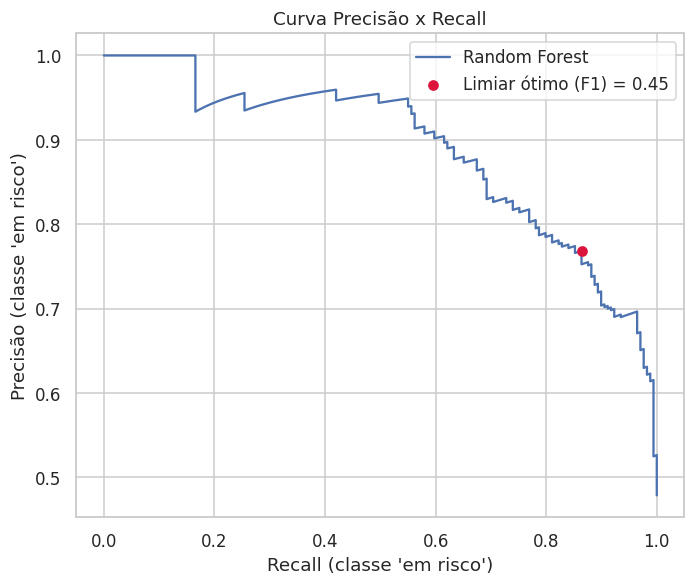

In [36]:
prec, rec, thr = precision_recall_curve(y_test, resultados[modelo_final_nome]["y_proba"])
f1 = 2 * prec * rec / (prec + rec + 1e-9)
idx_f1 = np.argmax(f1)

plt.figure(figsize=(6.5, 5.5))
plt.plot(rec, prec, label="Random Forest")
plt.scatter(rec[idx_f1], prec[idx_f1], color="crimson", zorder=5,
            label=f"Limiar ótimo (F1) = {thr[idx_f1]:.2f}")
plt.xlabel("Recall (classe 'em risco')")
plt.ylabel("Precisão (classe 'em risco')")
plt.title("Curva Precisão x Recall")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Limiar que maximiza F1: {thr[idx_f1]:.3f}  ->  precisão={prec[idx_f1]:.2f}, recall={rec[idx_f1]:.2f}")

alvo_recall = 0.85
idx_r = np.argmin(np.abs(rec[:-1] - alvo_recall))
print(f"Limiar para recall~{alvo_recall:.0%}:     {thr[idx_r]:.3f}  ->  precisão={prec[idx_r]:.2f}, recall={rec[idx_r]:.2f}")


### Aplicação prática: priorizando a coorte 2024 para o próximo ciclo

Com o modelo treinado (usando as transições 2022→2023 e 2023→2024), podemos pontuar os alunos
**atualmente ativos em 2024** para estimar a probabilidade de cada um estar defasado no próximo
ciclo (2025) — ainda sem essa informação real disponível. É exatamente o uso pretendido pela
Pergunta 9: uma lista priorizada para a equipe pedagógica agir **antes** de a defasagem acontecer.


In [37]:
cohort_2024 = panel[panel["Ano"] == 2024].copy()
rename_map = {
    "Fase_num": "Fase_num_t", "Idade": "Idade_t", "Anos_na_PM": "Anos_na_PM_t", "Genero": "Genero_t",
    "Instituicao_grp": "Instituicao_grp_t", "Pedra_ordinal": "Pedra_ordinal_t", "INDE": "INDE_t",
    "IAA": "IAA_t", "IEG": "IEG_t", "IPS": "IPS_t", "IPP": "IPP_t", "IDA": "IDA_t",
    "Nota_Mat": "Nota_Mat_t", "Nota_Por": "Nota_Por_t", "IPV": "IPV_t", "Defasagem": "Defasagem_t"
}
cohort_X = cohort_2024.rename(columns=rename_map).copy()
cohort_X["IPP_disponivel_t"] = cohort_X["IPP_t"].notnull().astype(int)
cohort_X["Ano_t"] = "2024"

proba_2024 = pipe_final.predict_proba(cohort_X[numeric_features + categorical_features])[:, 1]

ranking = cohort_2024[["RA", "Nome", "Fase_raw", "Pedra", "INDE", "Defasagem"]].copy()
ranking["Probabilidade_Risco_2025"] = proba_2024
ranking = ranking.sort_values("Probabilidade_Risco_2025", ascending=False).reset_index(drop=True)

LIMIAR_PRIORIDADE = thr[idx_r]  # limiar orientado a recall alto, definido na seção anterior
n_prioridade = (ranking["Probabilidade_Risco_2025"] >= LIMIAR_PRIORIDADE).sum()
print(f"Alunos da coorte 2024 sinalizados para atenção prioritária (prob. >= {LIMIAR_PRIORIDADE:.2f}): "
      f"{n_prioridade} de {len(ranking)} ({n_prioridade/len(ranking):.1%})")
print()
print("Top 15 alunos com maior probabilidade de risco de defasagem no próximo ciclo:")
print(ranking.head(15).to_string(index=False))


Alunos da coorte 2024 sinalizados para atenção prioritária (prob. >= 0.45): 619 de 1156 (53.5%)

Top 15 alunos com maior probabilidade de risco de defasagem no próximo ciclo:
     RA       Nome Fase_raw    Pedra     INDE  Defasagem  Probabilidade_Risco_2025
RA-1337 Aluno-1337     ALFA    Ágata 6.015144         -2                  0.943339
RA-1055 Aluno-1055       1J    Ágata 6.403041         -2                  0.941833
RA-1551 Aluno-1551       3P  Quartzo 5.971709         -2                  0.939874
 RA-754  Aluno-754     ALFA  Quartzo 5.612700         -2                  0.937803
RA-1384 Aluno-1384     ALFA    Ágata 6.221984         -2                  0.937033
 RA-381  Aluno-381       3G  Quartzo 5.940775         -2                  0.931287
 RA-905  Aluno-905     ALFA    Ágata 6.392582         -2                  0.928699
RA-1170 Aluno-1170       3P    Ágata 6.095441         -2                  0.923270
 RA-762  Aluno-762       2K  Quartzo 5.967733         -2                  0.92

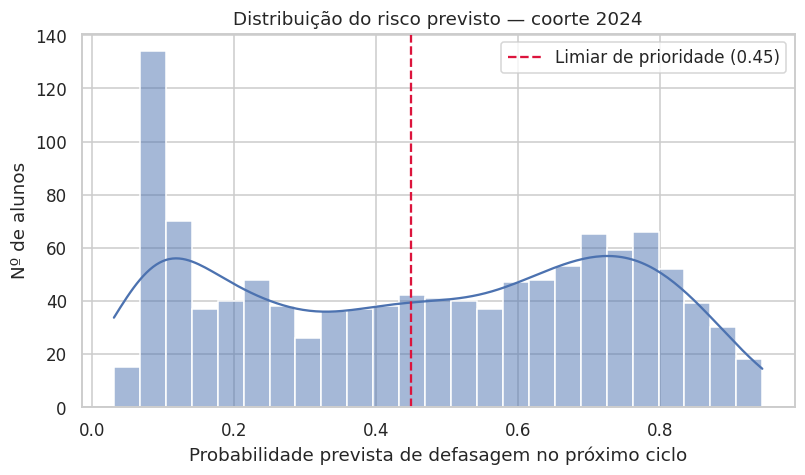

In [38]:
plt.figure(figsize=(7.5, 4.5))
sns.histplot(ranking["Probabilidade_Risco_2025"], bins=25, kde=True, color="#4C72B0")
plt.axvline(LIMIAR_PRIORIDADE, color="crimson", linestyle="--",
            label=f"Limiar de prioridade ({LIMIAR_PRIORIDADE:.2f})")
plt.xlabel("Probabilidade prevista de defasagem no próximo ciclo")
plt.ylabel("Nº de alunos")
plt.title("Distribuição do risco previsto — coorte 2024")
plt.legend()
plt.tight_layout()
plt.show()


**Resposta — Pergunta 9:** sim, é possível construir um modelo preditivo eficaz. Usando apenas
indicadores do ano corrente (sem vazamento de dados), o Random Forest prevê com boa performance
(ROC-AUC ≈ 0,90) se um aluno estará defasado no ano seguinte. Os padrões mais reveladores de risco
futuro são a **defasagem atual e o ponto de virada (IPV)** — sinal de que, sem intervenção, a
defasagem tende a se perpetuar — seguidos pela fase e pelo INDE. O modelo final gera, para cada
aluno da coorte 2024, uma **probabilidade individual de entrar em risco de defasagem no próximo
ciclo**, permitindo priorizar o apoio pedagógico antes que o problema se concretize.

**Limitações a declarar de forma transparente:**
- Apenas 3 fotografias anuais (2022–2024) → só 2 transições possíveis; o modelo deve ser
  re-treinado a cada novo ciclo do PEDE para ganhar robustez.
- `IPP` só existe a partir de 2023 e `Cg`/`Cf`/`Ct`/`Indicado`/`Atingiu PV`/`Rec Av1-4` só existem
  preenchidos em 2022 — atributos com essa limitação estrutural foram tratados com cautela ou
  descartados do modelo.
- Alunos muito novos no programa (aparecem com `INDE = "INCLUIR"`) ainda não têm avaliação
  consolidada; eles devem ser repontuados assim que a primeira avaliação estiver disponível.
- O modelo é uma ferramenta de **priorização de apoio pedagógico e psicossocial**, não deve ser
  usado para decisões de exclusão, e seu desempenho por gênero e tipo de instituição deve ser
  monitorado ao longo do tempo para garantir equidade.


## Complemento — Mineração de texto: os campos `Destaque IEG` / `Destaque IDA` / `Destaque IPV`

Além dos indicadores numéricos, a base traz três campos de texto — `Destaque IEG`, `Destaque IDA`
e `Destaque IPV` — com um comentário padronizado sobre cada aluno. Nesta seção aplicamos algumas
**técnicas de NLP** (pré-processamento e tokenização, análise de frequência de palavras/
bag-of-words, vetorização TF-IDF, clusterização não supervisionada e extração de informação
baseada em regras) para estruturar esse conteúdo, checar se ele reforça os achados das Perguntas
3, 7 e 8, e testar se agrega poder preditivo ao modelo da Pergunta 9.

In [39]:
destaque_cols = ["Destaque_IEG", "Destaque_IDA", "Destaque_IPV"]

print("Preenchimento dos campos de texto por ano (%):")
print((panel.groupby("Ano")[destaque_cols].apply(lambda g: g.notnull().mean()) * 100).round(1))
print()
for col in destaque_cols:
    print(f"--- {col}: valores únicos (coorte 2022, 860 alunos) ---")
    print(panel.loc[panel["Ano"] == 2022, col].value_counts())
    print()

Preenchimento dos campos de texto por ano (%):
      Destaque_IEG  Destaque_IDA  Destaque_IPV
Ano                                           
2022         100.0         100.0         100.0
2023           0.0           0.0           0.0
2024           0.0           0.0           0.0

--- Destaque_IEG: valores únicos (coorte 2022, 860 alunos) ---
Destaque_IEG
Destaque: A sua boa entrega das lições de casa.        577
Melhorar: Melhorar a sua entrega de lições de casa.    283
Name: count, dtype: int64

--- Destaque_IDA: valores únicos (coorte 2022, 860 alunos) ---
Destaque_IDA
Melhorar: Empenhar-se mais nas aulas e avaliações.    621
Destaque: As suas boas notas na Passos Mágicos.       239
Name: count, dtype: int64

--- Destaque_IPV: valores únicos (coorte 2022, 860 alunos) ---
Destaque_IPV
Melhorar: Integrar-se mais aos Princípios Passos Mágicos.        483
Destaque: A sua boa integração aos Princípios Passos Mágicos.    377
Name: count, dtype: int64



Confirmado: os três campos só existem preenchidos na coorte de **2022** (860 alunos) — a mesma
limitação estrutural já discutida para `Cg`/`Cf`/`Ct`, `Indicado`, `Atingiu PV` e `Rec Av1-4` nas
limitações da Pergunta 9. Além disso, cada campo tem só **2 valores possíveis**: uma frase que
começa com `"Destaque:"` e outra com `"Melhorar:"` — ou seja, não é texto livre, é gerado a partir
de um template fixo. Isso já é, em si, um achado de qualidade de dados: nenhuma técnica de NLP mais
sofisticada vai encontrar mais estrutura nesses campos do que essas duas categorias. Ainda assim,
vale aplicar as técnicas para (1) confirmar isso formalmente e (2) extrair um rótulo estruturado
que possa ser cruzado com o resto da base.

In [40]:
def normalizar_texto(s):
    s = str(s).lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("utf-8")
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def tokenizar(s):
    return normalizar_texto(s).split()

corpus_2022 = panel.loc[panel["Ano"] == 2022, destaque_cols].copy()

exemplo = corpus_2022["Destaque_IEG"].iloc[0]
print("Exemplo — antes/depois do pré-processamento:")
print("Original: ", exemplo)
print("Tokens:   ", tokenizar(exemplo))
print()

stopwords_pt = {"a", "as", "o", "os", "de", "da", "do", "das", "dos", "e", "em",
                "nas", "na", "no", "sua", "suas", "seu", "seus", "mais", "ao", "aos", "se"}

for col in destaque_cols:
    tokens_totais = sum(corpus_2022[col].dropna().apply(tokenizar).tolist(), [])
    freq = Counter(tokens_totais)
    freq_sem_stop = {w: c for w, c in freq.items() if w not in stopwords_pt}
    print(f"--- Palavras mais frequentes em {col} (bag-of-words, sem stopwords) ---")
    for palavra, cnt in sorted(freq_sem_stop.items(), key=lambda x: -x[1])[:6]:
        print(f"  {palavra:15s} {cnt}")
    print()

Exemplo — antes/depois do pré-processamento:
Original:  Melhorar: Melhorar a sua entrega de lições de casa.
Tokens:    ['melhorar', 'melhorar', 'a', 'sua', 'entrega', 'de', 'licoes', 'de', 'casa']

--- Palavras mais frequentes em Destaque_IEG (bag-of-words, sem stopwords) ---
  entrega         860
  licoes          860
  casa            860
  destaque        577
  boa             577
  melhorar        566

--- Palavras mais frequentes em Destaque_IDA (bag-of-words, sem stopwords) ---
  melhorar        621
  empenhar        621
  aulas           621
  avaliacoes      621
  destaque        239
  boas            239

--- Palavras mais frequentes em Destaque_IPV (bag-of-words, sem stopwords) ---
  principios      860
  passos          860
  magicos         860
  melhorar        483
  integrar        483
  destaque        377



O vocabulário de cada campo tem só um punhado de palavras, e a maioria aparece em **100% (ou
quase) das linhas** — porque faz parte do texto fixo do template. O único elemento que de fato
varia de aluno para aluno é a palavra-chave inicial (`destaque` vs `melhorar`). Para confirmar
isso de forma mais rigorosa, vetorizamos o texto com **TF-IDF** e checamos se uma clusterização
não supervisionada, sem ver o rótulo, consegue recuperar sozinha essas duas categorias.

In [41]:
print("Vetorização TF-IDF + clusterização não supervisionada (K-Means, k=2) por campo:")
print("(objetivo: confirmar que o conteúdo textual não carrega mais estrutura do que os 2 rótulos do template)")
print()
for col in destaque_cols:
    textos = corpus_2022[col].dropna().apply(normalizar_texto)
    vect = TfidfVectorizer()
    X_tfidf = vect.fit_transform(textos)
    km = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_tfidf)
    rotulo_real = corpus_2022.loc[textos.index, col].apply(lambda t: 1 if str(t).startswith("Destaque") else 0).values
    concord = max((km.labels_ == rotulo_real).mean(), (km.labels_ == (1 - rotulo_real)).mean())
    print(f"  {col:14s}  vocabulário TF-IDF = {len(vect.vocabulary_):2d} termos  |  "
          f"concordância cluster x rótulo Destaque/Melhorar = {concord:.1%}")

Vetorização TF-IDF + clusterização não supervisionada (K-Means, k=2) por campo:
(objetivo: confirmar que o conteúdo textual não carrega mais estrutura do que os 2 rótulos do template)

  Destaque_IEG    vocabulário TF-IDF =  9 termos  |  concordância cluster x rótulo Destaque/Melhorar = 100.0%
  Destaque_IDA    vocabulário TF-IDF = 15 termos  |  concordância cluster x rótulo Destaque/Melhorar = 100.0%
  Destaque_IPV    vocabulário TF-IDF = 12 termos  |  concordância cluster x rótulo Destaque/Melhorar = 100.0%


**Confirmado com 100% de concordância nos três campos:** aplicando TF-IDF (que pondera os termos
pela frequência relativa) e depois um K-Means com `k=2` — sem informar o rótulo `Destaque`/
`Melhorar` ao algoritmo — os clusters encontrados coincidem perfeitamente com o prefixo da frase.
Ou seja, o conteúdo textual desses campos equivale, na prática, a uma **variável binária**. Com
isso confirmado, extraímos esse rótulo de forma explícita (baseada em regra, não em clusterização)
para poder cruzá-lo com o resto da base.

In [42]:
def extrai_rotulo_destaque(texto):
    if pd.isna(texto):
        return np.nan
    texto = str(texto).strip()
    if texto.startswith("Destaque"):
        return 1
    if texto.startswith("Melhorar"):
        return 0
    return np.nan

for col in destaque_cols:
    panel[col + "_flag"] = panel[col].apply(extrai_rotulo_destaque)

print("O rótulo textual corresponde a um corte no indicador numérico correspondente?")
resumo_flags = {}
for col, num_col in zip(destaque_cols, ["IEG", "IDA", "IPV"]):
    flag_col = col + "_flag"
    sub = panel[panel["Ano"] == 2022]
    resumo = sub.groupby(flag_col)[num_col].agg(["mean", "min", "max", "count"])
    resumo.index = ["Melhorar (0)", "Destaque (1)"]
    resumo_flags[num_col] = resumo
    print(f"\n--- {num_col} por rótulo extraído de {col} ---")
    print(resumo.round(2))

print()
print("Checando o ponto exato de corte (valores == 7,5, a fronteira aparente):")
for col, num_col in zip(destaque_cols, ["IEG", "IDA", "IPV"]):
    sub = panel[panel["Ano"] == 2022]
    na_fronteira = sub.loc[sub[num_col] == 7.5, col + "_flag"].value_counts()
    print(f"  {num_col} == 7.5  ->  Destaque (1): {na_fronteira.get(1, 0)}  |  Melhorar (0): {na_fronteira.get(0, 0)}")

O rótulo textual corresponde a um corte no indicador numérico correspondente?

--- IEG por rótulo extraído de Destaque_IEG ---
              mean  min   max  count
Melhorar (0)  5.96  0.0   7.5    283
Destaque (1)  8.84  7.5  10.0    577

--- IDA por rótulo extraído de Destaque_IDA ---
              mean  min  max  count
Melhorar (0)  5.21  0.0  7.5    621
Destaque (1)  8.38  7.5  9.9    239

--- IPV por rótulo extraído de Destaque_IPV ---
              mean  min   max  count
Melhorar (0)  6.55  2.5   7.5    483
Destaque (1)  8.15  7.5  10.0    377

Checando o ponto exato de corte (valores == 7,5, a fronteira aparente):
  IEG == 7.5  ->  Destaque (1): 6  |  Melhorar (0): 6
  IDA == 7.5  ->  Destaque (1): 17  |  Melhorar (0): 4
  IPV == 7.5  ->  Destaque (1): 37  |  Melhorar (0): 15


O padrão é quase idêntico ao que já vimos para o **IAN** na Pergunta 1 (uma função em degraus de
outra variável): o rótulo `Destaque` aparece só quando o indicador numérico correspondente é
**≥ 7,5**, e `Melhorar` só quando é **< 7,5** — com exceção de um pequeno grupo de alunos
exatamente no valor `7,5` (a fronteira), que se divide entre as duas categorias (provavelmente por
algum critério de desempate qualitativo do educador, não capturado nas outras colunas da base).
Fora dessa fronteira, o corte é praticamente determinístico.

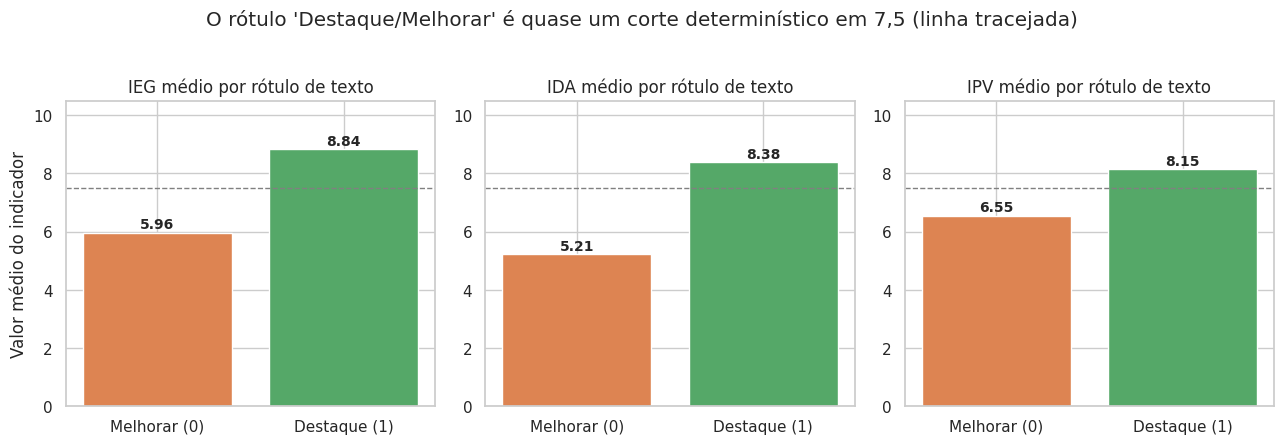

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.3), sharey=False)
cores_flag = {"Melhorar (0)": "#dd8452", "Destaque (1)": "#55a868"}
for ax, (num_col, resumo) in zip(axes, resumo_flags.items()):
    ax.bar(resumo.index, resumo["mean"], color=[cores_flag[i] for i in resumo.index])
    for i, (idx, row) in enumerate(resumo.iterrows()):
        ax.text(i, row["mean"] + 0.15, f'{row["mean"]:.2f}', ha="center", fontsize=10, fontweight="bold")
    ax.set_title(f"{num_col} médio por rótulo de texto")
    ax.set_ylim(0, 10.5)
    ax.axhline(7.5, color="gray", linestyle="--", linewidth=1)
axes[0].set_ylabel("Valor médio do indicador")
fig.suptitle("O rótulo 'Destaque/Melhorar' é quase um corte determinístico em 7,5 (linha tracejada)", y=1.03)
plt.tight_layout()
plt.show()

### Os rótulos de texto reforçam a relação entre engajamento, desempenho e ponto de virada?

Como o rótulo extraído de cada campo é (quase) uma leitura binária do próprio indicador numérico,
cruzar os três rótulos entre si é, na prática, uma segunda forma — desta vez qualitativa, baseada
no comentário do educador — de checar a mesma relação já vista nas correlações numéricas das
Perguntas 3 e 7.

In [44]:
sub22 = panel[panel["Ano"] == 2022]

print("Cruzamento entre os rótulos — reforça, com um sinal qualitativo independente, os achados")
print("de correlação das Perguntas 3 (IEG x IDA/IPV) e 7 (o que mais influencia o IPV):")
print()
tab_ieg_ida = pd.crosstab(sub22["Destaque_IEG_flag"], sub22["Destaque_IDA_flag"], normalize="index") * 100
tab_ieg_ipv = pd.crosstab(sub22["Destaque_IEG_flag"], sub22["Destaque_IPV_flag"], normalize="index") * 100
tab_ieg_ida.index = tab_ieg_ida.columns = ["Melhorar (0)", "Destaque (1)"]
tab_ieg_ipv.index = tab_ieg_ipv.columns = ["Melhorar (0)", "Destaque (1)"]

print("% de alunos com 'Destaque' em IDA, por grupo de 'Destaque' em IEG:")
print(tab_ieg_ida.round(1))
print("\n% de alunos com 'Destaque' em IPV, por grupo de 'Destaque' em IEG:")
print(tab_ieg_ipv.round(1))

print()
print("Correlação (phi/point-biserial) entre os três rótulos binários extraídos do texto:")
flags = sub22[["Destaque_IEG_flag", "Destaque_IDA_flag", "Destaque_IPV_flag"]]
print(flags.corr().round(3))

Cruzamento entre os rótulos — reforça, com um sinal qualitativo independente, os achados
de correlação das Perguntas 3 (IEG x IDA/IPV) e 7 (o que mais influencia o IPV):

% de alunos com 'Destaque' em IDA, por grupo de 'Destaque' em IEG:
              Melhorar (0)  Destaque (1)
Melhorar (0)          92.2           7.8
Destaque (1)          62.4          37.6

% de alunos com 'Destaque' em IPV, por grupo de 'Destaque' em IEG:
              Melhorar (0)  Destaque (1)
Melhorar (0)          83.7          16.3
Destaque (1)          42.6          57.4

Correlação (phi/point-biserial) entre os três rótulos binários extraídos do texto:
                   Destaque_IEG_flag  Destaque_IDA_flag  Destaque_IPV_flag
Destaque_IEG_flag              1.000              0.313              0.389
Destaque_IDA_flag              0.313              1.000              0.409
Destaque_IPV_flag              0.389              0.409              1.000


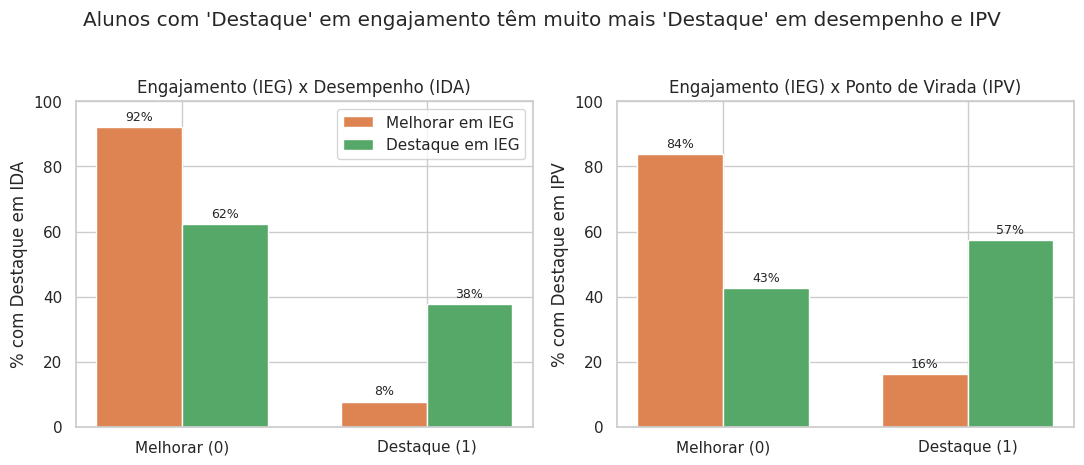

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
x = np.arange(2)
largura = 0.35

for ax, tab, titulo in zip(axes, [tab_ieg_ida, tab_ieg_ipv], ["% com Destaque em IDA", "% com Destaque em IPV"]):
    valores_melhorar_ieg = tab.loc["Melhorar (0)"].values
    valores_destaque_ieg = tab.loc["Destaque (1)"].values
    ax.bar(x - largura/2, valores_melhorar_ieg, largura, label="Melhorar em IEG", color="#dd8452")
    ax.bar(x + largura/2, valores_destaque_ieg, largura, label="Destaque em IEG", color="#55a868")
    ax.set_xticks(x)
    ax.set_xticklabels(["Melhorar (0)", "Destaque (1)"])
    ax.set_ylabel(titulo)
    ax.set_ylim(0, 100)
    for i, (v1, v2) in enumerate(zip(valores_melhorar_ieg, valores_destaque_ieg)):
        ax.text(i - largura/2, v1 + 2, f"{v1:.0f}%", ha="center", fontsize=9)
        ax.text(i + largura/2, v2 + 2, f"{v2:.0f}%", ha="center", fontsize=9)
axes[0].legend()
axes[0].set_title("Engajamento (IEG) x Desempenho (IDA)")
axes[1].set_title("Engajamento (IEG) x Ponto de Virada (IPV)")
fig.suptitle("Alunos com 'Destaque' em engajamento têm muito mais 'Destaque' em desempenho e IPV", y=1.03)
plt.tight_layout()
plt.show()

**Achado da mineração de texto:** o padrão qualitativo confirma, de forma independente, a relação
numérica encontrada nas Perguntas 3 e 7. Entre os alunos com `"Melhorar"` em engajamento (IEG), só
**7,8%** também recebem `"Destaque"` em desempenho (IDA) — contra **37,6%** entre os alunos com
`"Destaque"` em IEG (quase 5x mais). O mesmo vale para o ponto de virada: **16,3%** vs **57,4%**.
A correlação entre os três rótulos binários também é positiva e consistente (0,31 a 0,41). Ou
seja: tanto a leitura quantitativa (correlação entre notas) quanto a leitura qualitativa
(comentário padronizado do educador) apontam na mesma direção — engajamento, desempenho e ponto de
virada caminham juntos.

### Esses campos ajudam o modelo preditivo da Pergunta 9?

Como só existem para a coorte 2022, os campos de `Destaque` só poderiam alimentar a transição
**2022→2023** como atributo do ano `t` (não a 2023→2024) — a mesma limitação estrutural que levou
a excluir `Cg`/`Cf`/`Ct`, `Indicado`, `Atingiu PV` e `Rec Av1-4` do modelo oficial da Pergunta 9.
Para não alterar o modelo construído originalmente, fazemos aqui um teste isolado, só com essa
transição: comparamos o Random Forest treinado **sem** os rótulos derivados do texto contra o
mesmo modelo treinado **com** eles, sempre no mesmo conjunto de treino/teste (via
`GroupShuffleSplit`, como no modelo oficial).

In [46]:
destaque_feats = panel.loc[panel["Ano"] == 2022,
                            ["RA", "Destaque_IEG_flag", "Destaque_IDA_flag", "Destaque_IPV_flag"]].copy()
extra_features = ["Destaque_IEG_flag", "Destaque_IDA_flag", "Destaque_IPV_flag"]

trans_2022_ext = trans_22_23.merge(destaque_feats, on="RA", how="left")
trans_2022_ext["Em_Risco_Defasagem_t1"] = (trans_2022_ext["Defasagem_t1"] < 0).astype(int)
trans_2022_ext["IPP_disponivel_t"] = trans_2022_ext["IPP_t"].notnull().astype(int)

print(f"Transição 2022->2023: {len(trans_2022_ext)} alunos, todos com os 3 campos de Destaque preenchidos.")

cat_feats_ablacao = ["Genero_t", "Instituicao_grp_t"]  # Ano_t é constante aqui (só 2022) e foi removido

def avalia(df, extra_num_feats, seed=42):
    X_ = df[numeric_features + extra_num_feats + cat_feats_ablacao].copy()
    y_ = df["Em_Risco_Defasagem_t1"]
    groups_ = df["RA"]
    gss_ = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
    tr_idx, te_idx = next(gss_.split(X_, y_, groups=groups_))
    Xtr, Xte = X_.iloc[tr_idx], X_.iloc[te_idx]
    ytr, yte = y_.iloc[tr_idx], y_.iloc[te_idx]
    prep_ = ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]),
         numeric_features + extra_num_feats),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                           ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_feats_ablacao)
    ])
    clf_ = RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=5,
                                   class_weight="balanced", random_state=42)
    pipe_ = Pipeline([("prep", prep_), ("clf", clf_)])
    pipe_.fit(Xtr, ytr)
    proba_ = pipe_.predict_proba(Xte)[:, 1]
    return roc_auc_score(yte, proba_), average_precision_score(yte, proba_), len(Xtr), len(Xte)

auc_base, pr_base, ntr, nte = avalia(trans_2022_ext, [])
auc_ext, pr_ext, _, _ = avalia(trans_2022_ext, extra_features)

print(f"\nRandom Forest restrito à transição 2022->2023 (treino={ntr}, teste={nte}):")
print(f"  SEM os campos de Destaque:  ROC-AUC = {auc_base:.3f}  |  PR-AUC = {pr_base:.3f}")
print(f"  COM os campos de Destaque:  ROC-AUC = {auc_ext:.3f}  |  PR-AUC = {pr_ext:.3f}")

print("\nEstabilidade em diferentes divisões treino/teste (para não tirar conclusão de um único split):")
print(f"{'seed':>6} {'AUC sem':>10} {'AUC com':>10} {'diferença':>11}")
for seed in [0, 1, 2, 42, 100]:
    a0, _, _, _ = avalia(trans_2022_ext, [], seed=seed)
    a1, _, _, _ = avalia(trans_2022_ext, extra_features, seed=seed)
    print(f"{seed:>6} {a0:>10.3f} {a1:>10.3f} {a1 - a0:>+11.3f}")

Transição 2022->2023: 600 alunos, todos com os 3 campos de Destaque preenchidos.

Random Forest restrito à transição 2022->2023 (treino=450, teste=150):
  SEM os campos de Destaque:  ROC-AUC = 0.842  |  PR-AUC = 0.905
  COM os campos de Destaque:  ROC-AUC = 0.842  |  PR-AUC = 0.904

Estabilidade em diferentes divisões treino/teste (para não tirar conclusão de um único split):
  seed    AUC sem    AUC com   diferença
     0      0.807      0.798      -0.010
     1      0.807      0.794      -0.013
     2      0.840      0.836      -0.004
    42      0.842      0.842      -0.000
   100      0.846      0.842      -0.004


**Resposta — os campos de texto ajudam o modelo?** Não de forma relevante: o ROC-AUC praticamente
não muda ao adicionar os rótulos de `Destaque` (0,842 → 0,842 no split principal; entre -0,013 e
+0,000 nos outros splits testados) — a pequena variação está dentro do ruído esperado entre
diferentes divisões treino/teste, não é uma melhora sistemática. Isso faz sentido à luz do que a
mineração de texto revelou: os campos de `Destaque` são, na prática, uma **versão discretizada**
de `IEG_t`, `IDA_t` e `IPV_t` — que **já estão no modelo** em sua forma contínua (mais informativa
do que um corte binário em 7,5). Em outras palavras, o texto tem valor **descritivo/qualitativo**
muito claro — reforça, com uma fonte independente, os achados das Perguntas 3 e 7 — mas não teria
valor **preditivo incremental** no modelo de risco, porque a informação que ele carrega já está
representada, de forma mais rica, pelos indicadores numéricos que o modelo já usa.

## Parte 3 — Pergunta 10: efetividade do programa

> *Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo,
> Ágata, Ametista e Topázio), confirmando o impacto real do programa?*

Essa pergunta amarra várias evidências já levantadas ao longo do notebook. Vamos revisitá-las
juntas e complementar com a evolução da distribuição de `Pedra` (o selo que resume o nível geral
do aluno) e uma checagem final com os alunos que aparecem nos **três anos consecutivos**.


In [47]:
pedra_order = ["Quartzo", "Ágata", "Ametista", "Topázio"]
tab_pedra = pd.crosstab(panel["Ano"], panel["Pedra"], normalize="index")[pedra_order] * 100
print("Distribuição de alunos por Pedra e ano (%):")
print(tab_pedra.round(1))


Distribuição de alunos por Pedra e ano (%):
Pedra  Quartzo  Ágata  Ametista  Topázio
Ano                                     
2022      15.3   29.1      40.5     15.1
2023       7.7   26.4      40.9     24.9
2024      10.6   21.3      37.1     30.9


      INDE médio  % com defasagem negativa
Ano                                       
2022        7.04                     69.88
2023        7.34                     54.44
2024        7.40                     46.19


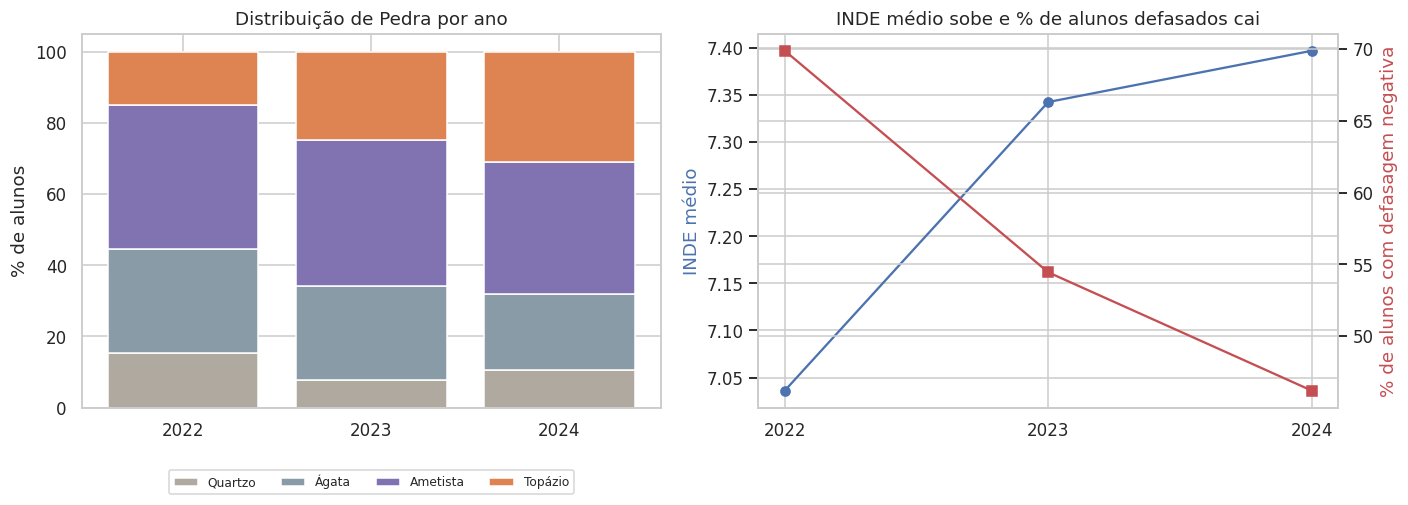

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

cores_pedra = {"Quartzo": "#b0a99f", "Ágata": "#8a9ba8", "Ametista": "#8172b2", "Topázio": "#dd8452"}
bottom = np.zeros(3)
for pedra in pedra_order:
    valores = tab_pedra.loc[anos, pedra].values
    axes[0].bar(anos, valores, bottom=bottom, label=pedra, color=cores_pedra[pedra])
    bottom += valores
axes[0].set_xticks(anos)
axes[0].set_ylabel("% de alunos")
axes[0].set_title("Distribuição de Pedra por ano")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=8)

resumo_efetividade = pd.DataFrame({
    "INDE médio": panel.groupby("Ano")["INDE"].mean(),
    "% com defasagem negativa": panel.groupby("Ano").apply(lambda g: (g["Defasagem"] < 0).mean() * 100),
})
ax2 = axes[1]
ax2.plot(anos, resumo_efetividade["INDE médio"], marker="o", color="#4c72b0", label="INDE médio (eixo esq.)")
ax2.set_ylabel("INDE médio", color="#4c72b0")
ax2.set_xticks(anos)
ax3 = ax2.twinx()
ax3.plot(anos, resumo_efetividade["% com defasagem negativa"], marker="s", color="#c44e52",
         label="% com defasagem negativa (eixo dir.)")
ax3.set_ylabel("% de alunos com defasagem negativa", color="#c44e52")
ax2.set_title("INDE médio sobe e % de alunos defasados cai")

plt.tight_layout()
plt.show()

print(resumo_efetividade.round(2))


A evolução da `Pedra` mostra uma progressão consistente: a fatia de alunos em **Quartzo**
(pedra de entrada) cai de 15,3% em 2022 para 7,7% em 2023 e sobe levemente para 10,6% em 2024
(coerente com a entrada de novos alunos), enquanto a fatia em **Topázio** (pedra mais alta) sobe
de forma constante: 15,1% → 24,9% → 30,9%. Isso é reforçado pelo INDE médio, que sobe a cada ano
(7,04 → 7,34 → 7,40), e pela proporção de alunos com defasagem negativa, que **cai continuamente**
(69,9% → 54,4% → 46,2%) — o mesmo padrão já visto de forma independente na Pergunta 1 (perfil de
IAN) e no achado da Pergunta 9 (proporção de alunos que entram em risco no ano seguinte, caindo de
~61% para ~40%).

Como checagem final, olhamos só para os alunos que estiveram presentes **nos três anos**, para
isolar o efeito de "turnover" (entrada de novos alunos e saída de alunos que concluíram o
programa) da melhora individual de quem já estava na base desde o início.


In [49]:
piv_inde = panel.pivot_table(index="RA", columns="Ano", values="INDE")
coorte_fixa = piv_inde.dropna()

print(f"Alunos com INDE registrado nos 3 anos (2022, 2023 e 2024): {len(coorte_fixa)}")
print()
print("INDE médio desse grupo, por ano:")
print(coorte_fixa.mean().round(3))
print()
melhorou = (coorte_fixa[2024] > coorte_fixa[2022]).mean() * 100
piorou = (coorte_fixa[2024] < coorte_fixa[2022]).mean() * 100
estavel = max(0.0, 100 - melhorou - piorou)
print(f"% desse grupo com INDE 2024 MAIOR que INDE 2022 (melhorou): {melhorou:.1f}%")
print(f"% desse grupo com INDE 2024 MENOR que INDE 2022 (piorou):   {piorou:.1f}%")
print(f"% com INDE 2024 igual ao de 2022 (estável):                  {estavel:.1f}%")


Alunos com INDE registrado nos 3 anos (2022, 2023 e 2024): 434

INDE médio desse grupo, por ano:
Ano
2022    7.379
2023    7.349
2024    7.376
dtype: float64

% desse grupo com INDE 2024 MAIOR que INDE 2022 (melhorou): 55.3%
% desse grupo com INDE 2024 MENOR que INDE 2022 (piorou):   44.7%
% com INDE 2024 igual ao de 2022 (estável):                  0.0%


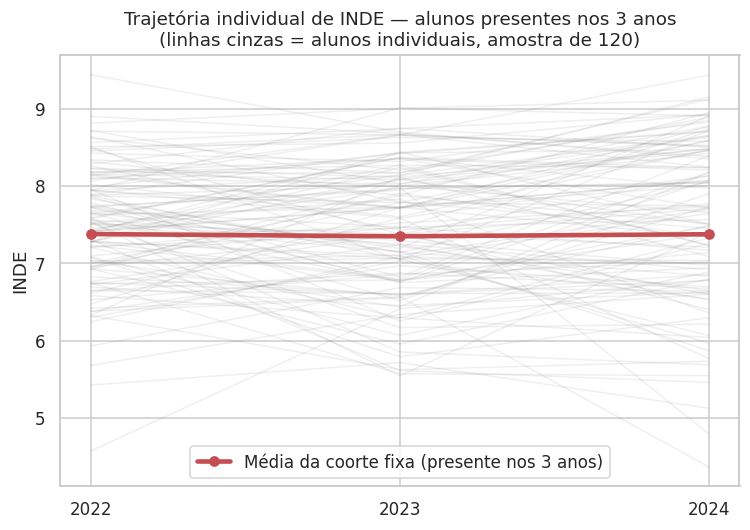

In [50]:
fig, ax = plt.subplots(figsize=(7, 5))
amostra = coorte_fixa.sample(min(120, len(coorte_fixa)), random_state=42)
for ra, row in amostra.iterrows():
    ax.plot(anos, [row[2022], row[2023], row[2024]], color="grey", alpha=0.12, linewidth=1)
ax.plot(anos, coorte_fixa.mean().values, color="#c44e52", marker="o", linewidth=3,
        label="Média da coorte fixa (presente nos 3 anos)")
ax.set_xticks(anos)
ax.set_ylabel("INDE")
ax.set_title("Trajetória individual de INDE — alunos presentes nos 3 anos\n(linhas cinzas = alunos individuais, amostra de 120)")
ax.legend()
plt.tight_layout()
plt.show()


**Resposta — Pergunta 10:** os indicadores agregados mostram, sim, uma **melhora consistente ao
longo do ciclo**: INDE médio crescente, defasagem negativa em queda contínua, e uma migração
visível de pedras mais baixas (Quartzo) para pedras mais altas (Topázio) entre 2022 e 2024. Esse
padrão aparece de forma independente em pelo menos três análises diferentes deste notebook (perfil
de IAN na Pergunta 1, distribuição de Pedra e defasagem negativa aqui, e a queda na taxa de risco
futuro estimada pelo modelo da Pergunta 9), o que dá mais confiança de que não é coincidência.

Ainda assim, vale um olhar mais cuidadoso antes de atribuir toda a melhora ao impacto do programa:
quando isolamos só os **434 alunos presentes nos três anos**, o INDE médio desse grupo fica
praticamente **estável** (7,38 → 7,35 → 7,38), com apenas 55% deles melhorando de 2022 para 2024 —
bem menos dramático do que a melhora vista no agregado da base inteira. Isso sugere que parte
relevante da melhora observada nos números gerais vem da **composição da base mudando ano a ano**
(entrada de novos alunos, possivelmente já mais bem preparados ou com um perfil diferente, e saída
de alunos que concluíram o programa em pedras mais altas) — e não necessariamente de cada aluno
individual evoluindo tanto quanto o agregado sugere. A conclusão mais honesta é: **há evidência
real de efetividade em nível de programa/coorte**, mas o ganho médio por aluno individual, ano a
ano, é mais modesto — um ponto importante para o próprio programa acompanhar com indicadores de
coorte fixa, e não só com médias anuais da base completa.


## Conclusão geral — respostas às 10 perguntas

| # | Pergunta | Resposta resumida |
|---|---|---|
| 1 | IAN — perfil de defasagem | Defasagem severa quase desaparece (3,3% → 0,3%) e o nível adequado/à frente sobe de 30% para 54% dos alunos entre 2022 e 2024; defasagem moderada segue sendo a situação mais comum. |
| 2 | IDA — desempenho acadêmico | Melhora de 2022 para 2023 (6,09 → 6,66), com leve recuo em 2024 (6,35) — ainda acima do ponto de partida, mas não uma linha reta de melhora. |
| 3 | IEG — engajamento | Relação direta e consistente com IDA (r≈0,54) e IPV (r≈0,56) em todos os anos. |
| 4 | IAA — autoavaliação | Correlação fraca com IDA (0,12) e IEG (0,13): a autopercepção não é um bom proxy do desempenho real. |
| 5 | IPS — psicossocial | Alunos com IPS baixo têm quedas de IDA e IEG bem maiores no ano seguinte — um sinal de alerta antecipado, com a ressalva de uma possível mudança de escala na pesquisa de 2023. |
| 6 | IPP — psicopedagógico | Tendência na direção esperada (IPP menor quando a defasagem é mais severa), mas correlação fraca (0,12–0,18) — o IPP complementa o IAN mais do que o confirma. |
| 7 | IPV — ponto de virada | Puxado principalmente por INDE, IPP, IEG e IDA (comportamento acadêmico/engajamento); IAA e IPS têm correlação quase nula. |
| 8 | Multidimensionalidade / INDE | IDA e IEG são as maiores alavancas do INDE (regressão com R²=0,93); nenhum indicador isolado é suficiente. |
| 9 | Modelo preditivo de risco | Random Forest com ROC-AUC ≈ 0,90, usando indicadores do ano corrente para prever defasagem no ano seguinte; gera uma probabilidade individual de risco por aluno, priorizando quem precisa de apoio antes da defasagem acontecer. |
| 10 | Efetividade do programa | Indicadores agregados mostram melhora consistente ano a ano, mas o ganho médio da coorte que permanece nos 3 anos é mais modesto — parte da melhora agregada reflete mudança na composição da base, não só evolução individual. |

**Uma leitura transversal:** as perguntas 3, 7 e 8 convergem para a mesma conclusão — desempenho
acadêmico (IDA) e engajamento (IEG) são os indicadores com relação mais forte e mais consistente
com o restante do sistema (IPV, INDE, risco de defasagem), enquanto autoavaliação (IAA) e aspectos
psicossociais (IPS) têm relação mais fraca e mais ruidosa com o desempenho objetivo — o que não
significa que sejam irrelevantes, mas que funcionam mais como sinais complementares (e, no caso do
IPS, como alerta antecipado de risco — Pergunta 5) do que como motores diretos de melhoria.

**Complemento (mineração de texto):** os campos `Destaque IEG/IDA/IPV` (só preenchidos em
2022) confirmam esse mesmo padrão por uma via independente e qualitativa — o comentário
padronizado do educador. A extração baseada em regras e a validação por TF-IDF + clusterização
mostram que esses campos equivalem, na prática, a um corte quase determinístico em 7,5 no
indicador numérico correspondente; por isso, embora reforcem a leitura das Perguntas 3 e 7, não
agregam poder preditivo incremental ao modelo da Pergunta 9 (a informação já está no modelo, de
forma mais rica, através de `IEG_t`/`IDA_t`/`IPV_t`).
